In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset/Images/water_body_1219.jpg
/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset/Images/water_body_1350.jpg
/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset/Images/water_body_6378.jpg
/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset/Images/water_body_1494.jpg
/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset/Images/water_body_907.jpg
/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset/Images/water_body_730.jpg
/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset/Images/water_body_697.jpg
/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset/Images/water_body_1476.jpg
/kaggle/input/datasets/franciscoesc

#  Environment Setup & Imports

In [6]:
import os
import sys
import random
import time
import warnings
warnings.filterwarnings("ignore")

#Core
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

#Visualization 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

#PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

#Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#Device 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#Print Summary 
print("=" * 55)
print("   Water Body Segmentation — MCCS Pipeline")
print("=" * 55)
print(f"  Python     : {sys.version.split()[0]}")
print(f"  PyTorch    : {torch.__version__}")
print(f"  Device     : {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"  GPU        : {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU Memory : {mem:.1f} GB")
print(f"  OpenCV     : {cv2.__version__}")
print(f"  NumPy      : {np.__version__}")
print("=" * 55)
print("  ✅ All libraries imported successfully.")
print("=" * 55)

   Water Body Segmentation — MCCS Pipeline
  Python     : 3.12.13
  PyTorch    : 2.10.0+cu128
  Device     : CUDA
  GPU        : Tesla T4
  GPU Memory : 15.6 GB
  OpenCV     : 4.13.0
  NumPy      : 2.4.6
  ✅ All libraries imported successfully.


# Dataset Download & Structure Exploration

In [7]:
import os, sys, warnings
import numpy as np
from pathlib import Path
from PIL import Image
warnings.filterwarnings("ignore")

DATA_ROOT = Path("/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies")

print("=" * 55)
print("  Full Dataset Tree")
print("=" * 55)
for p in sorted(DATA_ROOT.rglob("*")):
    depth  = len(p.relative_to(DATA_ROOT).parts)
    indent = "  " * depth
    if p.is_dir():
        print(f"{indent}📁 {p.name}/")
    else:
        print(f"{indent}📄 {p.name}")

#Auto-locate Images & Masks folders 
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}

IMG_DIR  = None
MASK_DIR = None

for p in sorted(DATA_ROOT.rglob("*")):
    if not p.is_dir():
        continue
    name = p.name.lower()
    has_images = any(f.suffix.lower() in IMG_EXTENSIONS for f in p.iterdir() if f.is_file())
    if not has_images:
        continue
    if "image" in name and IMG_DIR is None:
        IMG_DIR = p
    if "mask" in name and MASK_DIR is None:
        MASK_DIR = p


if IMG_DIR is None or MASK_DIR is None:
    candidates = []
    for p in sorted(DATA_ROOT.rglob("*")):
        if p.is_dir():
            files = [f for f in p.iterdir()
                     if f.is_file() and f.suffix.lower() in IMG_EXTENSIONS]
            if len(files) > 10:
                candidates.append((p, len(files)))
    candidates.sort(key=lambda x: x[0].name.lower())
    if len(candidates) >= 2 and IMG_DIR is None:
        IMG_DIR  = candidates[0][0]
        MASK_DIR = candidates[1][0]

print(f"\n  📂 Images folder : {IMG_DIR}")
print(f"  📂 Masks  folder : {MASK_DIR}")

#Count & validate pairs 
img_files  = sorted([f for f in IMG_DIR.iterdir()
                     if f.suffix.lower() in IMG_EXTENSIONS])
mask_files = sorted([f for f in MASK_DIR.iterdir()
                     if f.suffix.lower() in IMG_EXTENSIONS])

img_stems  = {f.stem for f in img_files}
mask_stems = {f.stem for f in mask_files}
matched    = img_stems & mask_stems
unmatched  = img_stems.symmetric_difference(mask_stems)

print(f"\n  Total images : {len(img_files)}")
print(f"  Total masks  : {len(mask_files)}")
print(f"  Matched pairs: {len(matched)}")
print(f"  Unmatched    : {len(unmatched)}")


sample_img  = Image.open(img_files[0])
sample_mask = Image.open(mask_files[0])
mask_arr    = np.array(sample_mask)

print("\n  ── Sample File Info ──────────────────────────────")
print(f"  Image  : {img_files[0].name}")
print(f"    Size : {sample_img.size}   Mode : {sample_img.mode}")
print(f"  Mask   : {mask_files[0].name}")
print(f"    Size : {sample_mask.size}   Mode : {sample_mask.mode}")
print(f"  Mask unique values  : {np.unique(mask_arr)}")
print(f"  Water pixels (255)  : {(mask_arr == 255).sum():,}")
print(f"  Land  pixels  (0)   : {(mask_arr == 0).sum():,}")
print(f"  Water coverage      : {(mask_arr == 255).mean()*100:.1f}%")

  Full Dataset Tree
  📁 Water Bodies Dataset/
    📁 Images/
      📄 water_body_1.jpg
      📄 water_body_10.jpg
      📄 water_body_100.jpg
      📄 water_body_1000.jpg
      📄 water_body_1002.jpg
      📄 water_body_1003.jpg
      📄 water_body_1004.jpg
      📄 water_body_1006.jpg
      📄 water_body_1008.jpg
      📄 water_body_101.jpg
      📄 water_body_1010.jpg
      📄 water_body_1011.jpg
      📄 water_body_1014.jpg
      📄 water_body_1015.jpg
      📄 water_body_1018.jpg
      📄 water_body_1019.jpg
      📄 water_body_102.jpg
      📄 water_body_1020.jpg
      📄 water_body_1021.jpg
      📄 water_body_1022.jpg
      📄 water_body_1023.jpg
      📄 water_body_1024.jpg
      📄 water_body_1026.jpg
      📄 water_body_1027.jpg
      📄 water_body_1028.jpg
      📄 water_body_1029.jpg
      📄 water_body_103.jpg
      📄 water_body_1030.jpg
      📄 water_body_1031.jpg
      📄 water_body_1033.jpg
      📄 water_body_1034.jpg
      📄 water_body_1036.jpg
      📄 water_body_1037.jpg
      📄 water_body_1039.j

# Exploratory Data Analysis (EDA)

Computing water coverage across all 2841 pairs...
(sampling 300 pairs for speed)

  Mean  water coverage : 32.89%
  Median water coverage: 26.50%
  Min   water coverage : 2.00%
  Max   water coverage : 100.00%
  Std   water coverage : 22.67%
  Images with >50% water : 56 / 300
  Images with <5%  water : 13 / 300


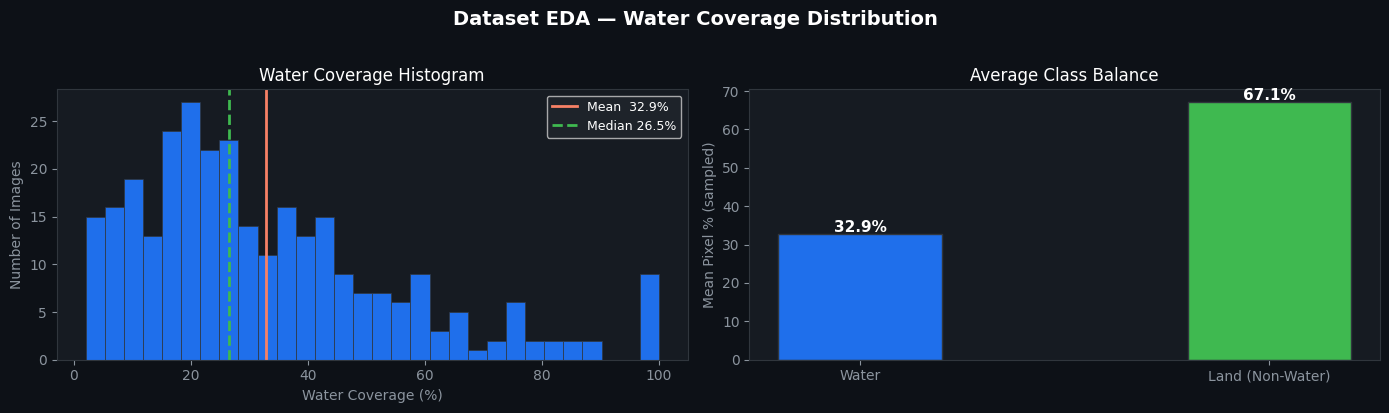

  ✅ Figure 1 saved: eda_coverage_distribution.png


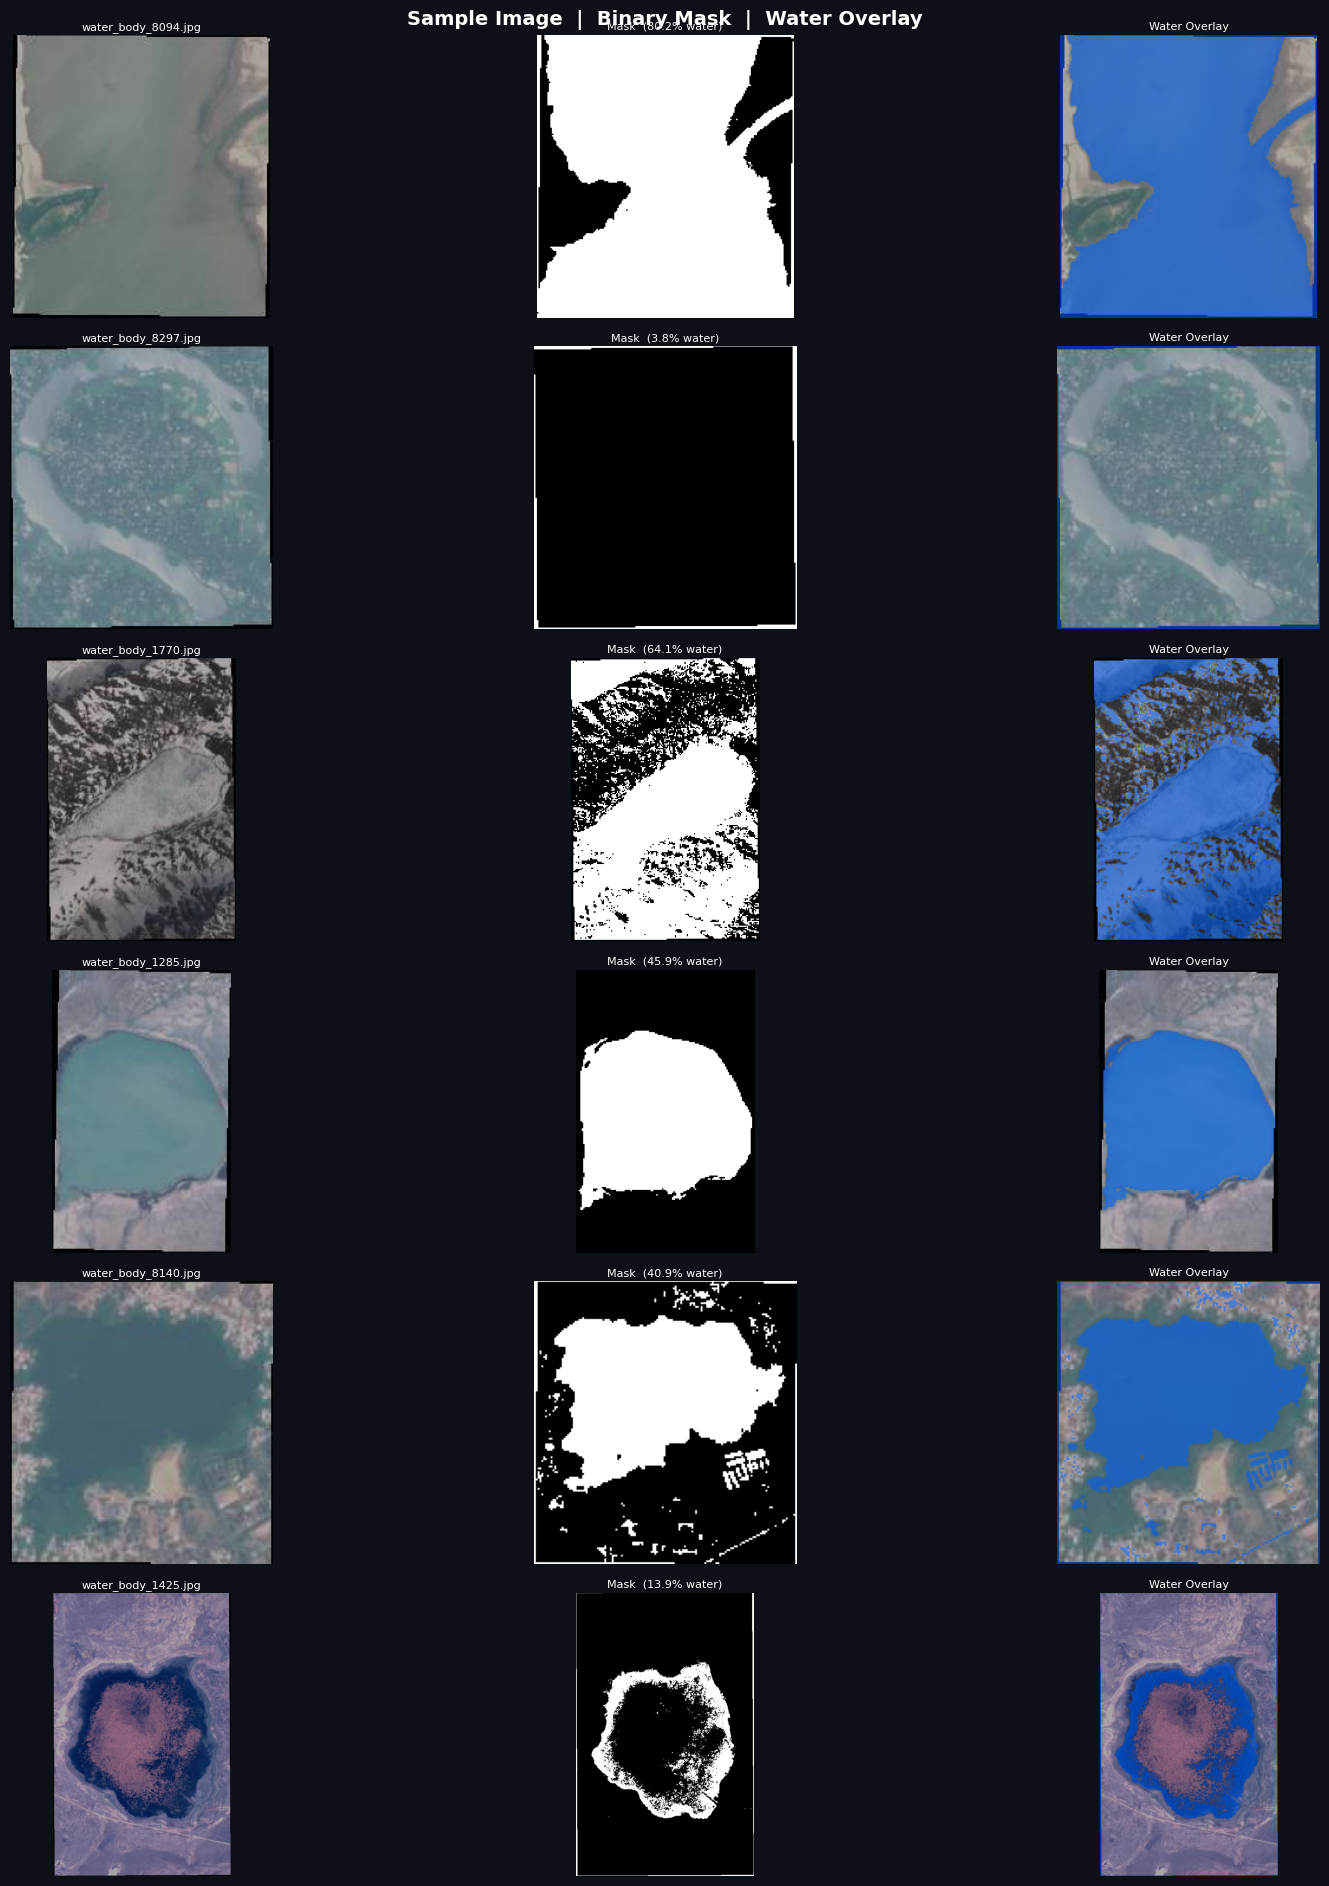

  ✅ Figure 2 saved: eda_sample_grid.png


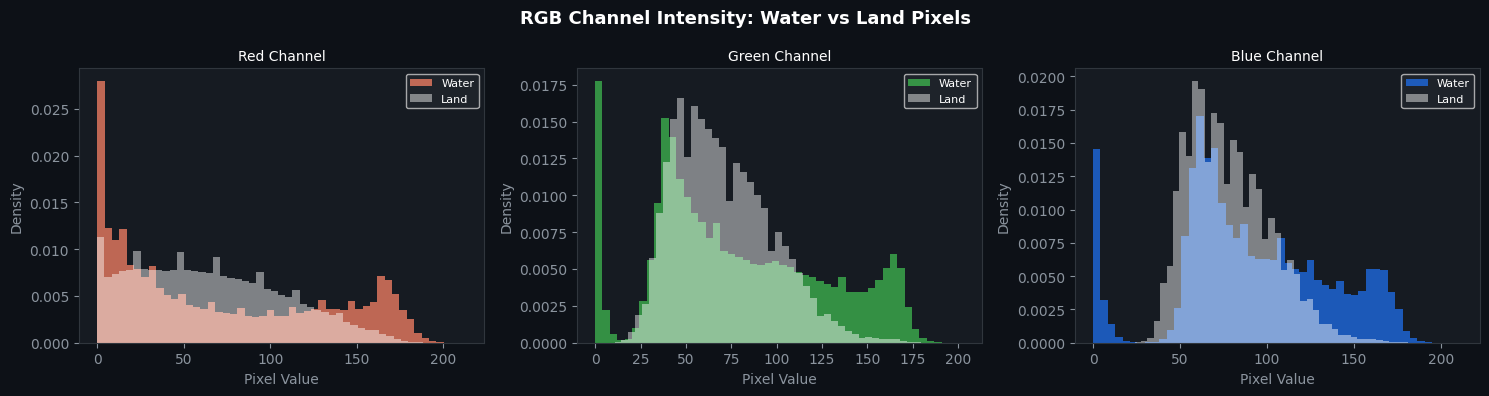

  ✅ Figure 3 saved: eda_channel_intensity.png

  EDA Summary
  Total pairs          : 2841
  Image resolution     : water_body_1.jpg → (2009, 2007, 3)
  Mask mode            : RGB → converted to grayscale → binarized at 127
  Mean water coverage  : 32.89%  (class imbalance confirmed)
  Training tile size   : 256 × 256  (will be set in Step 4)
  Batch size plan      : 16  (safe for T4 15.6 GB)


In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image

BASE    = Path("/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset")
IMG_DIR  = BASE / "Images"
MASK_DIR = BASE / "Masks"

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
img_files  = sorted([f for f in IMG_DIR.iterdir()  if f.suffix.lower() in IMG_EXTENSIONS])
mask_files = sorted([f for f in MASK_DIR.iterdir() if f.suffix.lower() in IMG_EXTENSIONS])


def load_pair(img_path, mask_path):
    img  = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("L"))   # grayscale
    mask_bin = (mask > 127).astype(np.uint8) * 255        # clean binary
    return img, mask_bin

# Dataset-wide water coverage statistics
print("Computing water coverage across all 2841 pairs...")
print("(sampling 300 pairs for speed)\n")

SAMPLE_N  = 300
sampled   = random.sample(list(zip(img_files, mask_files)), SAMPLE_N)
coverages = []

for img_p, mask_p in sampled:
    mask = np.array(Image.open(mask_p).convert("L"))
    mask_bin = (mask > 127).astype(np.uint8)
    coverages.append(mask_bin.mean() * 100)

coverages = np.array(coverages)

print(f"  Mean  water coverage : {coverages.mean():.2f}%")
print(f"  Median water coverage: {np.median(coverages):.2f}%")
print(f"  Min   water coverage : {coverages.min():.2f}%")
print(f"  Max   water coverage : {coverages.max():.2f}%")
print(f"  Std   water coverage : {coverages.std():.2f}%")
print(f"  Images with >50% water : {(coverages > 50).sum()} / {SAMPLE_N}")
print(f"  Images with <5%  water : {(coverages < 5).sum()} / {SAMPLE_N}")

# Coverage distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor="#0d1117")
fig.suptitle("Dataset EDA — Water Coverage Distribution",
             color="white", fontsize=14, fontweight="bold", y=1.02)

ax = axes[0]
ax.set_facecolor("#161b22")
ax.hist(coverages, bins=30, color="#1f6feb", edgecolor="#30363d", linewidth=0.5)
ax.axvline(coverages.mean(),   color="#f78166", linewidth=2, label=f"Mean  {coverages.mean():.1f}%")
ax.axvline(np.median(coverages), color="#3fb950", linewidth=2,
           linestyle="--", label=f"Median {np.median(coverages):.1f}%")
ax.set_xlabel("Water Coverage (%)", color="#8b949e")
ax.set_ylabel("Number of Images",   color="#8b949e")
ax.set_title("Water Coverage Histogram", color="white")
ax.tick_params(colors="#8b949e")
ax.legend(facecolor="#21262d", labelcolor="white", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor("#30363d")

# Class balance bar
ax2 = axes[1]
ax2.set_facecolor("#161b22")
mean_water = coverages.mean()
mean_land  = 100 - mean_water
bars = ax2.bar(["Water", "Land (Non-Water)"],
               [mean_water, mean_land],
               color=["#1f6feb", "#3fb950"], edgecolor="#30363d", width=0.4)
ax2.set_ylabel("Mean Pixel % (sampled)", color="#8b949e")
ax2.set_title("Average Class Balance", color="white")
ax2.tick_params(colors="#8b949e")
for bar, val in zip(bars, [mean_water, mean_land]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", color="white", fontsize=11, fontweight="bold")
for spine in ax2.spines.values(): spine.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("eda_coverage_distribution.png", dpi=120, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("  ✅ Figure 1 saved: eda_coverage_distribution.png")

# Visual grid: 6 random image / mask / overlay triplets
N_SHOW = 6
samples = random.sample(list(zip(img_files, mask_files)), N_SHOW)

fig = plt.figure(figsize=(18, N_SHOW * 3.2), facecolor="#0d1117")
fig.suptitle("Sample Image  |  Binary Mask  |  Water Overlay",
             color="white", fontsize=14, fontweight="bold")

for row_idx, (img_p, mask_p) in enumerate(samples):
    img, mask_bin = load_pair(img_p, mask_p)

    # Build overlay: semi-transparent blue on water pixels
    overlay = img.copy()
    water_px = mask_bin == 255
    overlay[water_px] = (
        img[water_px].astype(np.float32) * 0.45
        + np.array([0, 100, 255], dtype=np.float32) * 0.55
    ).astype(np.uint8)

    water_pct = water_px.mean() * 100

    for col_idx, (panel, title, cmap) in enumerate([
        (img,      f"{img_p.name}",         None),
        (mask_bin, f"Mask  ({water_pct:.1f}% water)", "gray"),
        (overlay,  "Water Overlay",          None),
    ]):
        ax = fig.add_subplot(N_SHOW, 3, row_idx * 3 + col_idx + 1)
        ax.imshow(panel, cmap=cmap)
        ax.set_title(title, color="white", fontsize=8, pad=4)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("eda_sample_grid.png", dpi=110, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("  ✅ Figure 2 saved: eda_sample_grid.png")

# Pixel intensity analysis
img_sample, mask_sample = load_pair(img_files[0], mask_files[0])
water_pixels  = img_sample[mask_sample == 255]
land_pixels   = img_sample[mask_sample == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor="#0d1117")
fig.suptitle("RGB Channel Intensity: Water vs Land Pixels",
             color="white", fontsize=13, fontweight="bold")

channel_colors = ["#f78166", "#3fb950", "#1f6feb"]   # R G B
channel_names  = ["Red Channel", "Green Channel", "Blue Channel"]

for c, (color, name) in enumerate(zip(channel_colors, channel_names)):
    ax = axes[c]
    ax.set_facecolor("#161b22")
    ax.hist(water_pixels[:, c], bins=50, alpha=0.75, color=color,
            label="Water", density=True)
    ax.hist(land_pixels[:, c],  bins=50, alpha=0.45, color="white",
            label="Land",  density=True)
    ax.set_title(name,  color="white", fontsize=10)
    ax.set_xlabel("Pixel Value", color="#8b949e")
    ax.set_ylabel("Density",     color="#8b949e")
    ax.tick_params(colors="#8b949e")
    ax.legend(facecolor="#21262d", labelcolor="white", fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("eda_channel_intensity.png", dpi=110, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("  ✅ Figure 3 saved: eda_channel_intensity.png")

# Summary
print("\n" + "=" * 55)
print("  EDA Summary")
print("=" * 55)
print(f"  Total pairs          : {len(img_files)}")
print(f"  Image resolution     : {img_files[0].name} → {img_sample.shape}")
print(f"  Mask mode            : RGB → converted to grayscale → binarized at 127")
print(f"  Mean water coverage  : {coverages.mean():.2f}%  (class imbalance confirmed)")
print(f"  Training tile size   : 256 × 256  (will be set in Step 4)")
print(f"  Batch size plan      : 16  (safe for T4 15.6 GB)")
print("=" * 55)

# Dataset Class, Augmentation & DataLoaders

  DataLoader Verification
  Train samples  : 1,988
  Val   samples  : 426
  Test  samples  : 427
  Total          : 2,841

  Batch image shape : torch.Size([16, 3, 256, 256])
  Batch mask  shape : torch.Size([16, 1, 256, 256])
  Image dtype       : torch.float32
  Mask  dtype       : torch.float32
  Image value range : [-2.118, 2.100]
  Mask  unique vals : [0.0, 1.0]
  Train batches/epoch: 124
  Val   batches/epoch: 27


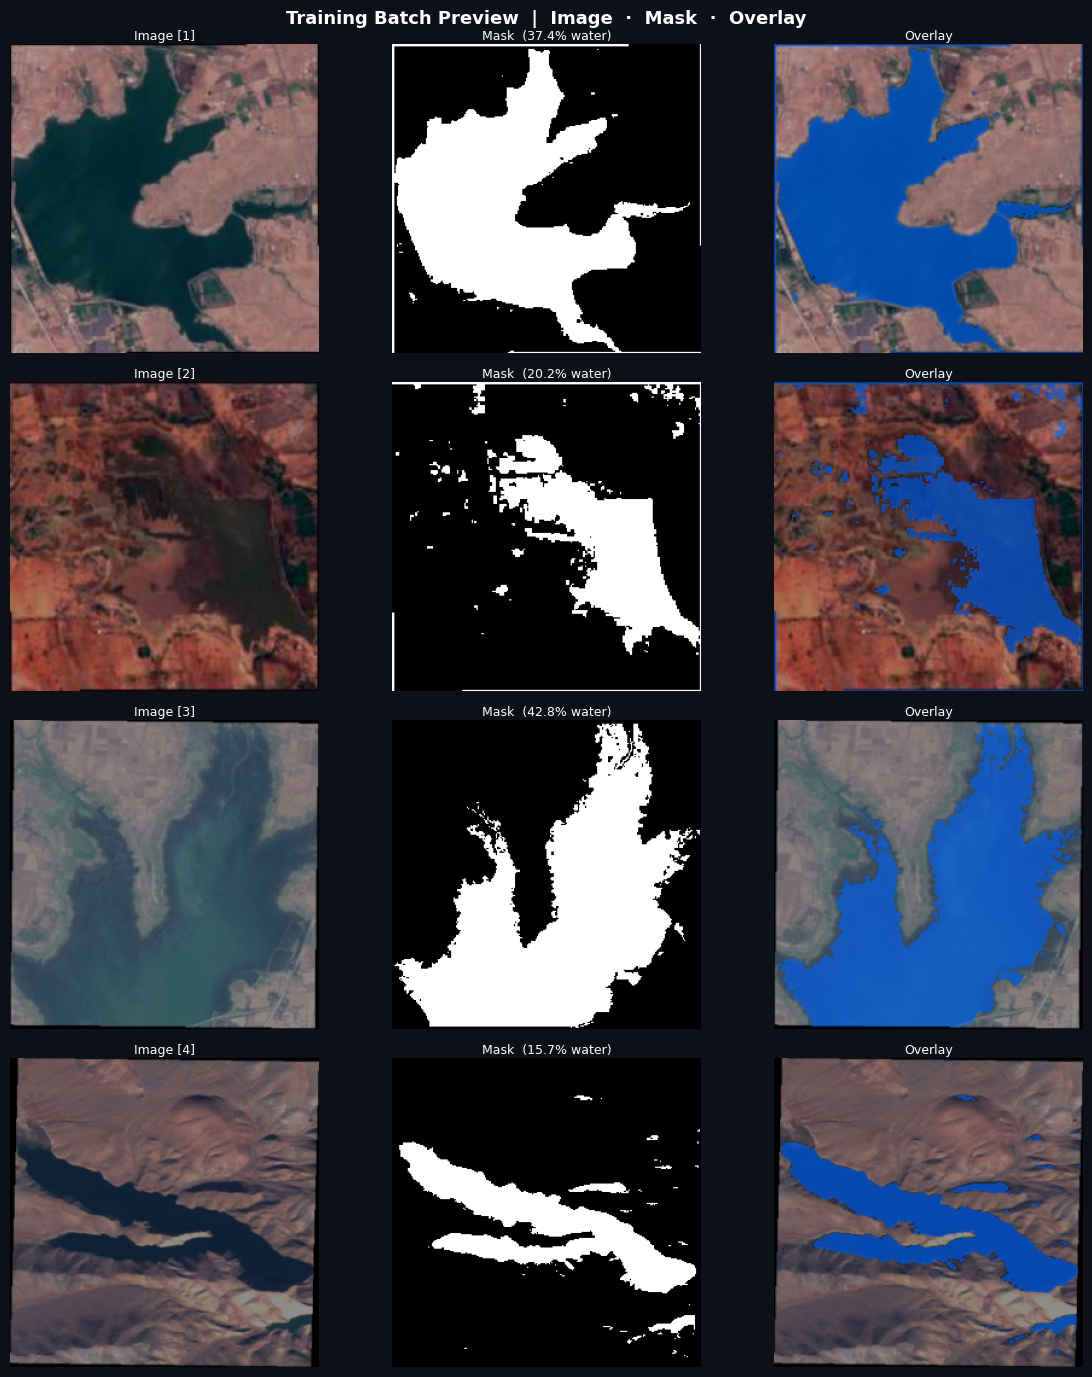

  ✅ Figure saved: dataloader_preview.png


In [9]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

# ── Global config 
TILE_SIZE  = 256   
BATCH_SIZE = 16      
NUM_WORKERS= 2       
SEED       = 42

BASE     = Path("/kaggle/input/datasets/franciscoescobar/satellite-images-of-water-bodies/Water Bodies Dataset")
IMG_DIR  = BASE / "Images"
MASK_DIR = BASE / "Masks"

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
img_files  = sorted([f for f in IMG_DIR.iterdir()  if f.suffix.lower() in IMG_EXTENSIONS])
mask_files = sorted([f for f in MASK_DIR.iterdir() if f.suffix.lower() in IMG_EXTENSIONS])

# Dataset Class
class WaterBodyDataset(Dataset):
    """
    Loads (image, mask) pairs for water body segmentation.

    Key design decisions:
      - Masks are RGB on disk → converted to grayscale → binarized at 127
      - Images are resized to TILE_SIZE × TILE_SIZE (256×256)
      - Augmentation applied only during training (augment=True)
      - ImageNet normalization on images (matches encoder expectations)
    """

    # ImageNet statistics — standard for satellite RGB
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_paths, mask_paths, tile_size=256, augment=False):
        assert len(img_paths) == len(mask_paths), "Mismatch between images and masks"
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.tile_size  = tile_size
        self.augment    = augment

        # Image: resize → tensor → normalize
        self.img_tf = transforms.Compose([
            transforms.Resize((tile_size, tile_size),
                               interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize(mean=self.MEAN, std=self.STD),
        ])

    def __len__(self):
        return len(self.img_paths)

    def _augment(self, img: np.ndarray, mask: np.ndarray):
        """
        Consistent spatial augmentations applied to BOTH image and mask.
        Mask uses nearest-neighbor to preserve binary values.
        """
        # Horizontal flip
        if random.random() > 0.5:
            img  = cv2.flip(img,  1)
            mask = cv2.flip(mask, 1)

        # Vertical flip
        if random.random() > 0.5:
            img  = cv2.flip(img,  0)
            mask = cv2.flip(mask, 0)

        # Random 90° rotation (0 / 90 / 180 / 270)
        k = random.randint(0, 3)
        if k > 0:
            img  = np.rot90(img,  k).copy()
            mask = np.rot90(mask, k).copy()

        # Brightness / contrast jitter — image only, not mask
        if random.random() > 0.5:
            alpha = random.uniform(0.75, 1.25)   # contrast
            beta  = random.uniform(-20,  20)     # brightness offset
            img   = np.clip(img.astype(np.float32) * alpha + beta,
                            0, 255).astype(np.uint8)

        return img, mask

    def __getitem__(self, idx):
        # Load image 
        img = np.array(Image.open(self.img_paths[idx]).convert("RGB"))

        # Load mask: RGB → grayscale → binary {0,1} 
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))
        mask = (mask > 127).astype(np.uint8)   # 1 = water, 0 = land

        # Augment (training only) 
        if self.augment:
            img, mask = self._augment(img, mask)

        # Resize mask (nearest to keep binary) 
        mask_resized = cv2.resize(mask,
                                  (self.tile_size, self.tile_size),
                                  interpolation=cv2.INTER_NEAREST)

        # Image → normalized tensor [3, H, W] 
        img_pil    = Image.fromarray(img)
        img_tensor = self.img_tf(img_pil)                         # [3, 256, 256]

        # Mask → float tensor [1, H, W] 
        mask_tensor = torch.from_numpy(mask_resized).unsqueeze(0).float()  # [1, 256, 256]

        return img_tensor, mask_tensor


# Train / Val / Test split  (70 / 15 / 15)
total      = len(img_files)
n_train    = int(0.70 * total)
n_val      = int(0.15 * total)
n_test     = total - n_train - n_val

# Pair images and masks, shuffle with fixed seed, then split
paired = list(zip(img_files, mask_files))
random.seed(SEED)
random.shuffle(paired)

train_pairs = paired[:n_train]
val_pairs   = paired[n_train : n_train + n_val]
test_pairs  = paired[n_train + n_val:]

train_img,  train_mask  = zip(*train_pairs)
val_img,    val_mask    = zip(*val_pairs)
test_img,   test_mask   = zip(*test_pairs)

# Instantiate datasets 
train_ds = WaterBodyDataset(train_img, train_mask,
                            tile_size=TILE_SIZE, augment=True)
val_ds   = WaterBodyDataset(val_img,   val_mask,
                            tile_size=TILE_SIZE, augment=False)
test_ds  = WaterBodyDataset(test_img,  test_mask,
                            tile_size=TILE_SIZE, augment=False)

# DataLoaders 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

# Verify a batch
sample_imgs, sample_masks = next(iter(train_loader))

print("=" * 55)
print("  DataLoader Verification")
print("=" * 55)
print(f"  Train samples  : {len(train_ds):,}")
print(f"  Val   samples  : {len(val_ds):,}")
print(f"  Test  samples  : {len(test_ds):,}")
print(f"  Total          : {len(train_ds)+len(val_ds)+len(test_ds):,}")
print()
print(f"  Batch image shape : {sample_imgs.shape}")
print(f"  Batch mask  shape : {sample_masks.shape}")
print(f"  Image dtype       : {sample_imgs.dtype}")
print(f"  Mask  dtype       : {sample_masks.dtype}")
print(f"  Image value range : [{sample_imgs.min():.3f}, {sample_imgs.max():.3f}]")
print(f"  Mask  unique vals : {sample_masks.unique().tolist()}")
print(f"  Train batches/epoch: {len(train_loader)}")
print(f"  Val   batches/epoch: {len(val_loader)}")
print("=" * 55)

# Visualize 4 samples from the training loader
# (denormalize before display)
MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(tensor):
    """Reverse ImageNet normalization for visualization."""
    return torch.clamp(tensor * STD_T + MEAN_T, 0, 1)

N_SHOW = 4
fig, axes = plt.subplots(N_SHOW, 3, figsize=(12, N_SHOW * 3.5),
                          facecolor="#0d1117")
fig.suptitle("Training Batch Preview  |  Image  ·  Mask  ·  Overlay",
             color="white", fontsize=13, fontweight="bold")

for i in range(N_SHOW):
    img_vis  = denormalize(sample_imgs[i]).permute(1,2,0).numpy()
    mask_vis = sample_masks[i].squeeze().numpy()

    # Build overlay
    overlay = img_vis.copy()
    water_px = mask_vis == 1
    overlay[water_px] = (
        img_vis[water_px] * 0.40
        + np.array([0.0, 0.39, 1.0]) * 0.60
    )
    overlay = np.clip(overlay, 0, 1)
    water_pct = water_px.mean() * 100

    for j, (panel, title, cmap) in enumerate([
        (img_vis,  f"Image [{i+1}]",               None),
        (mask_vis, f"Mask  ({water_pct:.1f}% water)", "gray"),
        (overlay,  "Overlay",                        None),
    ]):
        ax = axes[i][j]
        ax.imshow(panel, cmap=cmap, vmin=0, vmax=1 if cmap == "gray" else None)
        ax.set_title(title, color="white", fontsize=9, pad=3)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("dataloader_preview.png", dpi=110, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("  ✅ Figure saved: dataloader_preview.png")

# U-Net Architecture

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Building Blocks
class DoubleConv(nn.Module):
    """
    The atomic U-Net unit:
        Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU

    BatchNorm stabilizes training and lets us use higher LR.
    Both convolutions use padding=1 to keep spatial dims unchanged.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class EncoderBlock(nn.Module):
    """
    Contracting path step:
        MaxPool(2×2)  →  DoubleConv
    Halves spatial resolution, doubles channels.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class DecoderBlock(nn.Module):
    """
    Expanding path step:
        ConvTranspose2d(×2)  →  cat(skip)  →  DoubleConv

    Skip connection from the matching encoder level is concatenated
    along the channel axis before the DoubleConv.
    F.interpolate handles any size mismatch from odd dimensions.
    """
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2,
                                       kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Align spatial size in case of rounding mismatch
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)   # concat on channel axis
        return self.conv(x)


# Full U-Net
class UNet(nn.Module):
    """
    U-Net for binary water segmentation.

    Encoder:    3 → 64 → 128 → 256 → 512
    Bottleneck: 512 → 1024
    Decoder:    1024 → 512 → 256 → 128 → 64
    Head:       64 → 1  (sigmoid → probability map)

    Args:
        in_channels : input image channels (3 for RGB)
        base_filters: feature maps in first encoder block (default 64)
    """
    def __init__(self, in_channels=3, base_filters=64):
        super().__init__()
        f = base_filters

        # Encoder 
        self.enc1 = DoubleConv(in_channels, f)       # [B,  64, 256, 256]
        self.enc2 = EncoderBlock(f,     f * 2)       # [B, 128, 128, 128]
        self.enc3 = EncoderBlock(f * 2, f * 4)       # [B, 256,  64,  64]
        self.enc4 = EncoderBlock(f * 4, f * 8)       # [B, 512,  32,  32]

        # Bottleneck 
        self.bottleneck = EncoderBlock(f * 8, f * 16) # [B,1024,  16,  16]

        # Decoder 
        self.dec4 = DecoderBlock(f * 16, f * 8,  f * 8)  # [B, 512, 32, 32]
        self.dec3 = DecoderBlock(f * 8,  f * 4,  f * 4)  # [B, 256, 64, 64]
        self.dec2 = DecoderBlock(f * 4,  f * 2,  f * 2)  # [B, 128,128,128]
        self.dec1 = DecoderBlock(f * 2,  f,      f)       # [B,  64,256,256]

        #  Output head 
        # 1×1 conv: 64 channels → 1 channel
        # Sigmoid squashes to [0,1] → water probability per pixel
        self.head = nn.Conv2d(f, 1, kernel_size=1)

        # Weight initialization 
        self._init_weights()

    def _init_weights(self):
        """Kaiming normal init for conv layers — best for ReLU networks."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)

    def forward(self, x):
        """
        Args:
            x : [B, 3, H, W]  normalized satellite image
        Returns:
            [B, 1, H, W]  water probability map ∈ [0, 1]
        """
        # Encoder — save skip tensors
        s1 = self.enc1(x)          # [B,   64, 256, 256]
        s2 = self.enc2(s1)         # [B,  128, 128, 128]
        s3 = self.enc3(s2)         # [B,  256,  64,  64]
        s4 = self.enc4(s3)         # [B,  512,  32,  32]

        # Bottleneck
        b  = self.bottleneck(s4)   # [B, 1024,  16,  16]

        # Decoder — pass skip connections
        d4 = self.dec4(b,  s4)     # [B,  512,  32,  32]
        d3 = self.dec3(d4, s3)     # [B,  256,  64,  64]
        d2 = self.dec2(d3, s2)     # [B,  128, 128, 128]
        d1 = self.dec1(d2, s1)     # [B,   64, 256, 256]

        # Head
        return torch.sigmoid(self.head(d1))  # [B, 1, 256, 256]


# Instantiate & verify
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet(in_channels=3, base_filters=64).to(DEVICE)

#  Parameter count 
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Forward pass with dummy input 
dummy = torch.randn(1, 3, 256, 256).to(DEVICE)
with torch.no_grad():
    dummy_out = model(dummy)

# GPU memory after model load 
if DEVICE == "cuda":
    mem_alloc = torch.cuda.memory_allocated() / 1e9
    mem_reserv= torch.cuda.memory_reserved()  / 1e9
else:
    mem_alloc = mem_reserv = 0.0

# Architecture summary (manual layer-by-layer)
print("=" * 55)
print("  U-Net Architecture Summary")
print("=" * 55)

summary_rows = [
    ("Layer",           "Output Shape",        "Channels"),
    ("─" * 20,          "─" * 18,              "─" * 10),
    ("Input",           "[B,  3, 256, 256]",   "3"),
    ("Encoder 1",       "[B, 64, 256, 256]",   "64"),
    ("Encoder 2",       "[B,128, 128, 128]",   "128"),
    ("Encoder 3",       "[B,256,  64,  64]",   "256"),
    ("Encoder 4",       "[B,512,  32,  32]",   "512"),
    ("Bottleneck",      "[B,1024, 16,  16]",   "1024"),
    ("Decoder 4 + s4",  "[B,512,  32,  32]",   "512"),
    ("Decoder 3 + s3",  "[B,256,  64,  64]",   "256"),
    ("Decoder 2 + s2",  "[B,128, 128, 128]",   "128"),
    ("Decoder 1 + s1",  "[B, 64, 256, 256]",   "64"),
    ("Output Head",     "[B,  1, 256, 256]",   "1"),
]

for name, shape, ch in summary_rows:
    print(f"  {name:<22} {shape:<22} {ch}")

print("=" * 55)
print(f"  Total parameters     : {total_params:>12,}")
print(f"  Trainable parameters : {trainable_params:>12,}")
print(f"  Input  shape         :  {dummy.shape}")
print(f"  Output shape         :  {dummy_out.shape}")
print(f"  Output range         :  [{dummy_out.min():.4f}, {dummy_out.max():.4f}]")
if DEVICE == "cuda":
    print(f"  GPU memory allocated :  {mem_alloc:.3f} GB")
    print(f"  GPU memory reserved  :  {mem_reserv:.3f} GB")
print("=" * 55)

  U-Net Architecture Summary
  Layer                  Output Shape           Channels
  ────────────────────   ──────────────────     ──────────
  Input                  [B,  3, 256, 256]      3
  Encoder 1              [B, 64, 256, 256]      64
  Encoder 2              [B,128, 128, 128]      128
  Encoder 3              [B,256,  64,  64]      256
  Encoder 4              [B,512,  32,  32]      512
  Bottleneck             [B,1024, 16,  16]      1024
  Decoder 4 + s4         [B,512,  32,  32]      512
  Decoder 3 + s3         [B,256,  64,  64]      256
  Decoder 2 + s2         [B,128, 128, 128]      128
  Decoder 1 + s1         [B, 64, 256, 256]      64
  Output Head            [B,  1, 256, 256]      1
  Total parameters     :   31,037,633
  Trainable parameters :   31,037,633
  Input  shape         :  torch.Size([1, 3, 256, 256])
  Output shape         :  torch.Size([1, 1, 256, 256])
  Output range         :  [0.0000, 1.0000]
  GPU memory allocated :  0.127 GB
  GPU memory reserved  :

# Loss Function (BCE + Dice) & Metrics (IoU, F1)

  Loss & Metrics — Verification on 1 Batch
  (untrained model — random weights)
  Batch size         : 16
  Pred  shape        : torch.Size([16, 1, 256, 256])
  Pred  range        : [0.0025, 0.9930]
  Mask  unique vals  : [0.0, 1.0]

  BCE + Dice Loss    : 0.6766

  IoU       : 0.2695
  F1 (Dice) : 0.4246
  Precision : 0.3653
  Recall    : 0.5069
  Accuracy  : 0.585


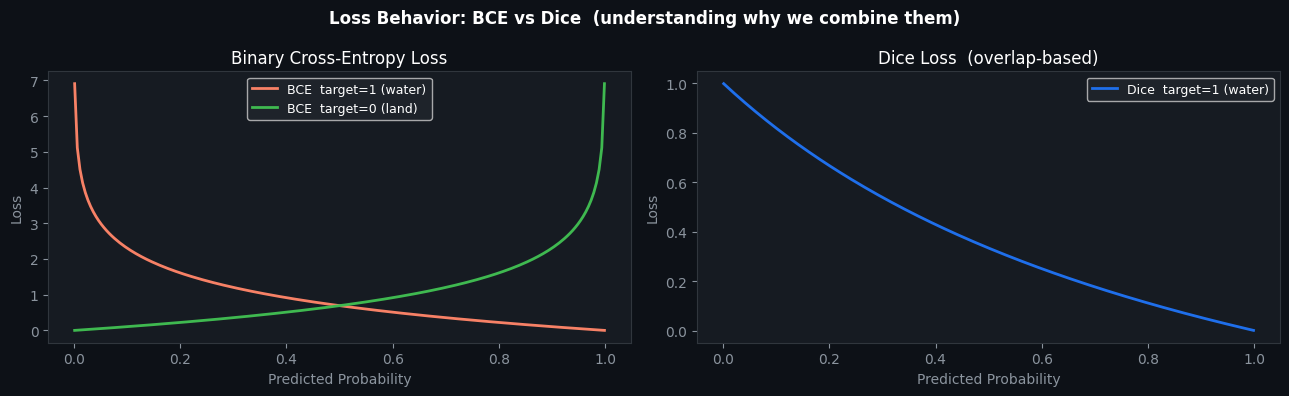

  ✅ Figure saved: loss_behavior.png


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


# Loss Function: BCE + Dice

class BCEDiceLoss(nn.Module):
    """
    Combined Binary Cross-Entropy + Dice Loss.

    Why both?
      - BCE  : penalizes each pixel independently → good probability calibration
      - Dice : optimizes overlap directly → robust to class imbalance
               (water ~32% of pixels, so pure BCE would ignore hard negatives)

    Total = α × BCE  +  (1 - α) × (1 - Dice)
    Default α = 0.5 gives equal weight to both terms.

    Dice formula:
        Dice = (2 × Σ(pred × target) + ε) / (Σpred + Σtarget + ε)
        Loss = 1 - Dice
    """

    def __init__(self, bce_weight=0.5, smooth=1e-6):
        super().__init__()
        self.bce_weight = bce_weight
        self.smooth     = smooth
        self.bce        = nn.BCELoss()

    def forward(self, pred, target):
        """
        Args:
            pred   : [B, 1, H, W]  sigmoid output ∈ [0, 1]
            target : [B, 1, H, W]  binary float  ∈ {0, 1}
        Returns:
            Scalar loss value.
        """
        # BCE term 
        bce_loss = self.bce(pred, target)

        # Dice term 
        pred_flat = pred.view(-1)
        tgt_flat  = target.view(-1)

        intersection = (pred_flat * tgt_flat).sum()
        dice_score   = (2.0 * intersection + self.smooth) / \
                       (pred_flat.sum() + tgt_flat.sum() + self.smooth)
        dice_loss    = 1.0 - dice_score

        # Combined 
        return self.bce_weight * bce_loss + (1.0 - self.bce_weight) * dice_loss


# Metrics

class SegmentationMetrics:
    """
    Computes pixel-level binary segmentation metrics.

    All metrics computed from the confusion matrix:
        TP, FP, FN, TN

    Metrics:
        IoU  (Intersection over Union) — primary metric for segmentation
        F1   (Dice coefficient)        — harmonic mean of precision & recall
        Precision                      — of predicted water, how much is correct
        Recall                         — of actual water, how much we detected
        Accuracy                       — overall pixel accuracy
    """

    def __init__(self, threshold=0.5, smooth=1e-6):
        self.threshold = threshold
        self.smooth    = smooth
        self._reset()

    def _reset(self):
        self.tp = self.fp = self.fn = self.tn = 0.0

    def update(self, pred, target):
        """
        Accumulate confusion matrix counts over a batch.
        Args:
            pred   : [B, 1, H, W] float probabilities
            target : [B, 1, H, W] float binary {0, 1}
        """
        with torch.no_grad():
            pred_bin = (pred >= self.threshold).float()
            tgt      = target.float()

            self.tp += (pred_bin * tgt).sum().item()
            self.fp += (pred_bin * (1 - tgt)).sum().item()
            self.fn += ((1 - pred_bin) * tgt).sum().item()
            self.tn += ((1 - pred_bin) * (1 - tgt)).sum().item()

    def compute(self):
        """Return dict of all metrics from accumulated counts."""
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        s = self.smooth

        iou       = (tp + s)       / (tp + fp + fn + s)
        f1        = (2*tp + s)     / (2*tp + fp + fn + s)
        precision = (tp + s)       / (tp + fp + s)
        recall    = (tp + s)       / (tp + fn + s)
        accuracy  = (tp + tn + s)  / (tp + tn + fp + fn + s)

        return {
            "iou"      : round(iou,       4),
            "f1"       : round(f1,        4),
            "precision": round(precision, 4),
            "recall"   : round(recall,    4),
            "accuracy" : round(accuracy,  4),
        }

    def reset(self):
        self._reset()


# Validate loss & metrics on a real batch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

criterion = BCEDiceLoss(bce_weight=0.5)
metrics   = SegmentationMetrics(threshold=0.5)

# Grab one batch from the train loader
sample_imgs, sample_masks = next(iter(train_loader))
sample_imgs  = sample_imgs.to(DEVICE)
sample_masks = sample_masks.to(DEVICE)

# Forward pass with untrained model
model.eval()
with torch.no_grad():
    preds = model(sample_imgs)          # [16, 1, 256, 256]
    loss  = criterion(preds, sample_masks)
    metrics.update(preds, sample_masks)
    batch_metrics = metrics.compute()
    metrics.reset()

print("=" * 55)
print("  Loss & Metrics — Verification on 1 Batch")
print("  (untrained model — random weights)")
print("=" * 55)
print(f"  Batch size         : {sample_imgs.shape[0]}")
print(f"  Pred  shape        : {preds.shape}")
print(f"  Pred  range        : [{preds.min():.4f}, {preds.max():.4f}]")
print(f"  Mask  unique vals  : {sample_masks.unique().tolist()}")
print()
print(f"  BCE + Dice Loss    : {loss.item():.4f}")
print()
print(f"  IoU       : {batch_metrics['iou']}")
print(f"  F1 (Dice) : {batch_metrics['f1']}")
print(f"  Precision : {batch_metrics['precision']}")
print(f"  Recall    : {batch_metrics['recall']}")
print(f"  Accuracy  : {batch_metrics['accuracy']}")
print("=" * 55)

# Visualize what BCE vs Dice penalizes
probs   = torch.linspace(0.001, 0.999, 200)
target1 = torch.ones(200)     # target = water (1)
target0 = torch.zeros(200)    # target = land  (0)

bce_fn  = nn.BCELoss(reduction="none")
bce_pos = bce_fn(probs, target1).numpy()   # cost of missing water
bce_neg = bce_fn(probs, target0).numpy()   # cost of false alarm

dice_pos = (1 - (2*probs + 1e-6) / (probs + 1 + 1e-6)).numpy()
dice_neg = (1 - (1e-6) / (probs + 1e-6)).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor="#0d1117")
fig.suptitle("Loss Behavior: BCE vs Dice  (understanding why we combine them)",
             color="white", fontsize=12, fontweight="bold")

ax = axes[0]
ax.set_facecolor("#161b22")
ax.plot(probs.numpy(), bce_pos, color="#f78166", lw=2, label="BCE  target=1 (water)")
ax.plot(probs.numpy(), bce_neg, color="#3fb950", lw=2, label="BCE  target=0 (land)")
ax.set_title("Binary Cross-Entropy Loss", color="white")
ax.set_xlabel("Predicted Probability", color="#8b949e")
ax.set_ylabel("Loss",                  color="#8b949e")
ax.tick_params(colors="#8b949e")
ax.legend(facecolor="#21262d", labelcolor="white", fontsize=9)
for sp in ax.spines.values(): sp.set_edgecolor("#30363d")

ax2 = axes[1]
ax2.set_facecolor("#161b22")
ax2.plot(probs.numpy(), dice_pos, color="#1f6feb", lw=2, label="Dice  target=1 (water)")
ax2.set_title("Dice Loss  (overlap-based)", color="white")
ax2.set_xlabel("Predicted Probability",     color="#8b949e")
ax2.set_ylabel("Loss",                      color="#8b949e")
ax2.tick_params(colors="#8b949e")
ax2.legend(facecolor="#21262d", labelcolor="white", fontsize=9)
for sp in ax2.spines.values(): sp.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("loss_behavior.png", dpi=110, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("  ✅ Figure saved: loss_behavior.png")

# Full Training Loop with Validation(AMP-safe loss + logits output from model)

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import time
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# FIX: Rebuild U-Net — output raw logits (no sigmoid)
\
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x):
        return self.conv(self.pool(x))

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode="bilinear", align_corners=False)
        return self.conv(torch.cat([skip, x], dim=1))

class UNet(nn.Module):
    def __init__(self, in_channels=3, base_filters=64):
        super().__init__()
        f = base_filters
        self.enc1       = DoubleConv(in_channels, f)
        self.enc2       = EncoderBlock(f,     f*2)
        self.enc3       = EncoderBlock(f*2,   f*4)
        self.enc4       = EncoderBlock(f*4,   f*8)
        self.bottleneck = EncoderBlock(f*8,   f*16)
        self.dec4       = DecoderBlock(f*16,  f*8,  f*8)
        self.dec3       = DecoderBlock(f*8,   f*4,  f*4)
        self.dec2       = DecoderBlock(f*4,   f*2,  f*2)
        self.dec1       = DecoderBlock(f*2,   f,    f)
        self.head       = nn.Conv2d(f, 1, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.bottleneck(s4)
        d4 = self.dec4(b,  s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)
        # ── Raw logits — NO sigmoid here ──────────────────
        return self.head(d1)          # [B, 1, H, W]  ∈ (-∞, +∞)


# FIX 2: AMP-safe BCE + Dice loss (operates on logits)
class BCEDiceLoss(nn.Module):
    """
    AMP-safe combined loss that accepts raw logits.
      - BCE  term : BCEWithLogitsLoss  (numerically stable, AMP-safe)
      - Dice term : sigmoid applied manually before overlap computation
    """
    def __init__(self, bce_weight=0.5, smooth=1e-6):
        super().__init__()
        self.bce_weight = bce_weight
        self.smooth     = smooth
        self.bce        = nn.BCEWithLogitsLoss()   # ← AMP-safe

    def forward(self, logits, target):
        """
        Args:
            logits : [B, 1, H, W]  raw model output (no sigmoid)
            target : [B, 1, H, W]  binary float {0, 1}
        """
        # BCE on logits — stable
        bce_loss = self.bce(logits, target)

        # Dice needs probabilities — apply sigmoid here
        probs     = torch.sigmoid(logits)
        p_flat    = probs.view(-1)
        t_flat    = target.view(-1)
        intersect = (p_flat * t_flat).sum()
        dice_loss = 1.0 - (2.0 * intersect + self.smooth) / \
                          (p_flat.sum() + t_flat.sum() + self.smooth)

        return self.bce_weight * bce_loss + (1.0 - self.bce_weight) * dice_loss


# FIX 3: Metrics — apply sigmoid to logits before thresholding
class SegmentationMetrics:
    def __init__(self, threshold=0.5, smooth=1e-6):
        self.threshold = threshold
        self.smooth    = smooth
        self._reset()

    def _reset(self):
        self.tp = self.fp = self.fn = self.tn = 0.0

    def update(self, logits, target):
        with torch.no_grad():
            probs    = torch.sigmoid(logits)          # ← convert logits → probs
            pred_bin = (probs >= self.threshold).float()
            tgt      = target.float()
            self.tp += (pred_bin * tgt).sum().item()
            self.fp += (pred_bin * (1 - tgt)).sum().item()
            self.fn += ((1 - pred_bin) * tgt).sum().item()
            self.tn += ((1 - pred_bin) * (1 - tgt)).sum().item()

    def compute(self):
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        s = self.smooth
        return {
            "iou"      : round((tp+s)/(tp+fp+fn+s),       4),
            "f1"       : round((2*tp+s)/(2*tp+fp+fn+s),   4),
            "precision": round((tp+s)/(tp+fp+s),           4),
            "recall"   : round((tp+s)/(tp+fn+s),           4),
            "accuracy" : round((tp+tn+s)/(tp+tn+fp+fn+s), 4),
        }

    def reset(self):
        self._reset()


# Fresh model, optimizer, scheduler
NUM_EPOCHS = 50
LR         = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE   = 8
CHECKPOINT = "/kaggle/working/best_model.pth"

model     = UNet(in_channels=3, base_filters=64).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                  T_max=NUM_EPOCHS, eta_min=1e-6)
criterion = BCEDiceLoss(bce_weight=0.5)
scaler    = GradScaler(enabled=(DEVICE == "cuda"))

print("=" * 55)
print("  Training Configuration")
print("=" * 55)
print(f"  Epochs         : {NUM_EPOCHS}")
print(f"  LR             : {LR}")
print(f"  Weight Decay   : {WEIGHT_DECAY}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Early Stopping : patience={PATIENCE}")
print(f"  AMP            : enabled on {DEVICE.upper()}")
print(f"  Model output   : raw logits (sigmoid at inference)")
print(f"  Loss           : BCEWithLogitsLoss + Dice")
print("=" * 55)

# Training helpers
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    metrics    = SegmentationMetrics(threshold=0.5)

    for imgs, masks in loader:
        imgs  = imgs.to(device,  non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(device == "cuda")):
            logits = model(imgs)
            loss   = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        metrics.update(logits.detach(), masks)

    return total_loss / len(loader.dataset), metrics.compute()


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    metrics    = SegmentationMetrics(threshold=0.5)

    for imgs, masks in loader:
        imgs  = imgs.to(device,  non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast(enabled=(device == "cuda")):
            logits = model(imgs)
            loss   = criterion(logits, masks)

        total_loss += loss.item() * imgs.size(0)
        metrics.update(logits, masks)

    return total_loss / len(loader.dataset), metrics.compute()


# Training loop
history = {
    "train_loss": [], "val_loss"  : [],
    "train_iou" : [], "val_iou"   : [],
    "train_f1"  : [], "val_f1"    : [],
    "train_recall":[],"val_recall" : [],
    "lr"        : [],
}

best_val_iou      = 0.0
epochs_no_improve = 0
training_start    = time.time()

print(f"\n{'Ep':>4} │ {'Train Loss':>10} │ {'Val Loss':>10} │ "
      f"{'Train IoU':>9} │ {'Val IoU':>9} │ {'Val F1':>7} │ "
      f"{'Val Rec':>7} │ {'LR':>9} │ {'Time':>6}")
print("─" * 100)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_m = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, DEVICE)
    val_loss, val_m = validate_one_epoch(
        model, val_loader, criterion, DEVICE)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_m["iou"])
    history["val_iou"].append(val_m["iou"])
    history["train_f1"].append(train_m["f1"])
    history["val_f1"].append(val_m["f1"])
    history["train_recall"].append(train_m["recall"])
    history["val_recall"].append(val_m["recall"])
    history["lr"].append(current_lr)

    elapsed   = time.time() - t0
    improved  = " ⬆ BEST" if val_m["iou"] > best_val_iou else ""

    print(f"{epoch:>4} │ {train_loss:>10.4f} │ {val_loss:>10.4f} │ "
          f"{train_m['iou']:>9.4f} │ {val_m['iou']:>9.4f} │ "
          f"{val_m['f1']:>7.4f} │ {val_m['recall']:>7.4f} │ "
          f"{current_lr:>9.2e} │ {elapsed:>5.1f}s{improved}")

    if val_m["iou"] > best_val_iou:
        best_val_iou      = val_m["iou"]
        epochs_no_improve = 0
        torch.save({
            "epoch"               : epoch,
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_iou"        : best_val_iou,
            "val_metrics"         : val_m,
            "history"             : history,
            "config": {
                "in_channels" : 3,
                "base_filters": 64,
                "tile_size"   : TILE_SIZE,
                "threshold"   : 0.5,
            }
        }, CHECKPOINT)
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\n  ⏹  Early stopping triggered at epoch {epoch}")
        break

# Summary
total_time  = time.time() - training_start
final_epoch = len(history["val_iou"])

print("\n" + "=" * 55)
print("  Training Complete")
print("=" * 55)
print(f"  Epochs trained      : {final_epoch}")
print(f"  Total time          : {total_time/60:.1f} min")
print(f"  Best Val IoU        : {best_val_iou:.4f}")
print(f"  Final Train Loss    : {history['train_loss'][-1]:.4f}")
print(f"  Final Val   Loss    : {history['val_loss'][-1]:.4f}")
print(f"  Final Val   F1      : {history['val_f1'][-1]:.4f}")
print(f"  Checkpoint saved at : {CHECKPOINT}")
print("=" * 55)

  Training Configuration
  Epochs         : 50
  LR             : 0.0001
  Weight Decay   : 0.0001
  Batch Size     : 16
  Early Stopping : patience=8
  AMP            : enabled on CUDA
  Model output   : raw logits (sigmoid at inference)
  Loss           : BCEWithLogitsLoss + Dice

  Ep │ Train Loss │   Val Loss │ Train IoU │   Val IoU │  Val F1 │ Val Rec │        LR │   Time
────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │     0.5720 │     0.4946 │    0.4873 │    0.5719 │  0.7277 │  0.7965 │  9.99e-05 │  60.0s ⬆ BEST
   2 │     0.3844 │     0.3337 │    0.5829 │    0.6424 │  0.7823 │  0.7543 │  9.96e-05 │  58.8s ⬆ BEST
   3 │     0.3453 │     0.2956 │    0.6147 │    0.6784 │  0.8084 │  0.7786 │  9.91e-05 │  58.8s ⬆ BEST
   4 │     0.3223 │     0.3105 │    0.6374 │    0.6676 │  0.8007 │  0.7762 │  9.84e-05 │  57.8s
   5 │     0.2994 │     0.2736 │    0.6573 │    0.7017 │  0.8247 │  0.7983 │  9.76e-05 │  56.9s ⬆ BEST
   6 │     

# Training Curves & Final Test Set Evaluation

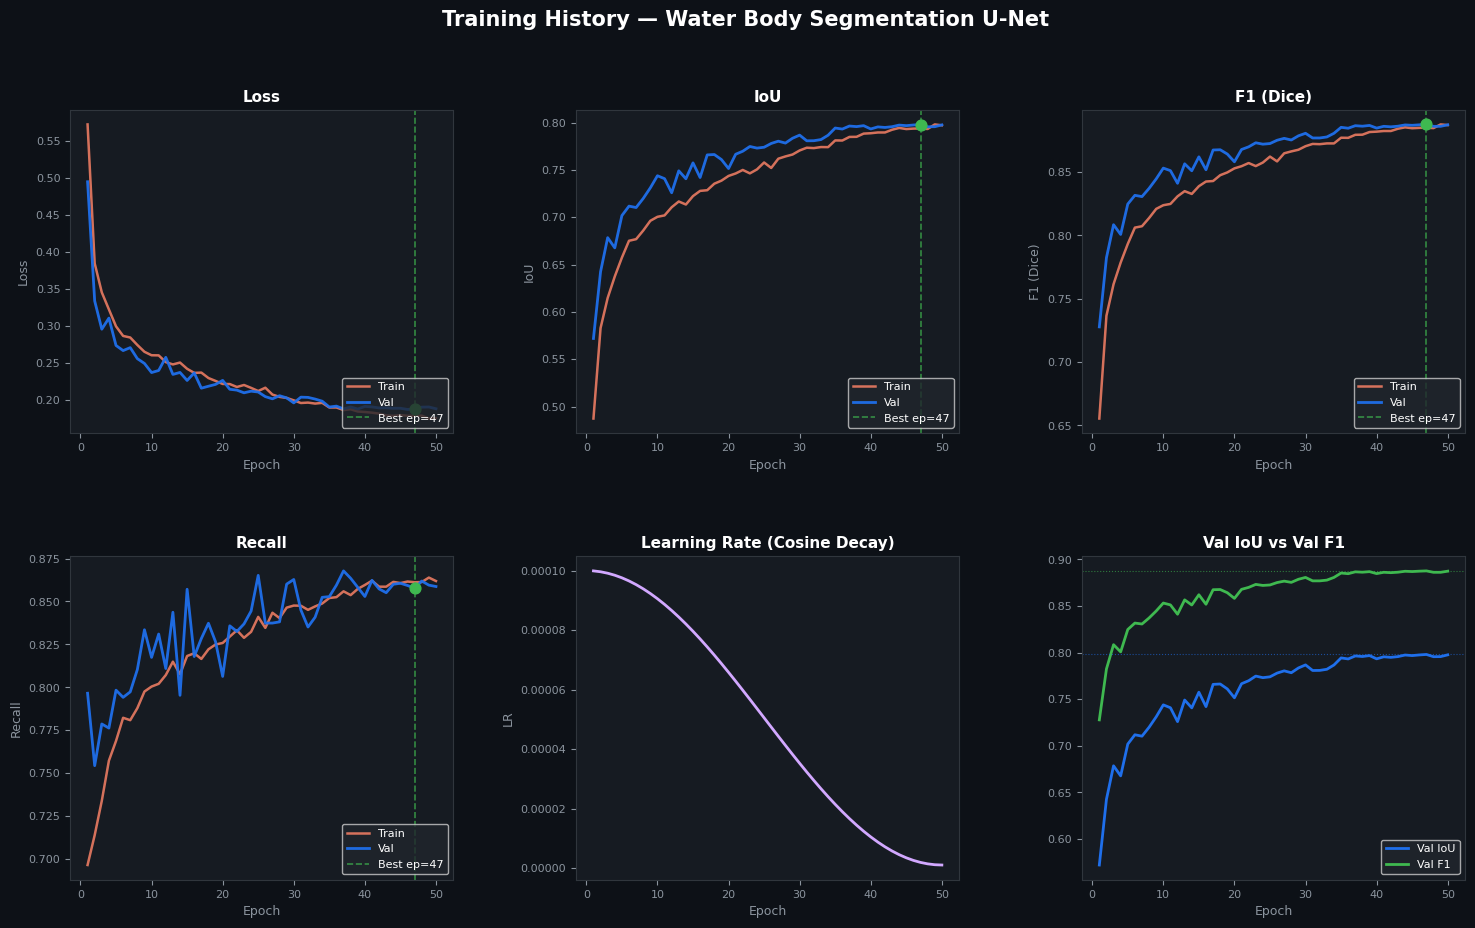

  ✅ Figure saved: training_curves.png

  Loading best checkpoint...
  Checkpoint epoch  : 47
  Checkpoint Val IoU: 0.7979

  Final Test Set Results  (427 images, never seen)
  Test Loss      : 0.2106
  Test IoU       : 0.7616
  Test F1 (Dice) : 0.8647
  Test Precision : 0.8876
  Test Recall    : 0.8429
  Test Accuracy  : 0.9136


In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Training curves — 4-panel figure
epochs = range(1, len(history["train_loss"]) + 1)

fig = plt.figure(figsize=(18, 10), facecolor="#0d1117")
fig.suptitle("Training History — Water Body Segmentation U-Net",
             color="white", fontsize=15, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.38, wspace=0.32)

panel_specs = [
    (gs[0, 0], "Loss",       "train_loss",   "val_loss",    "#f78166", "#1f6feb"),
    (gs[0, 1], "IoU",        "train_iou",    "val_iou",     "#f78166", "#1f6feb"),
    (gs[0, 2], "F1 (Dice)",  "train_f1",     "val_f1",      "#f78166", "#1f6feb"),
    (gs[1, 0], "Recall",     "train_recall", "val_recall",  "#f78166", "#1f6feb"),
]

best_epoch = np.argmax(history["val_iou"]) + 1

for spec, title, train_key, val_key, tc, vc in panel_specs:
    ax = fig.add_subplot(spec)
    ax.set_facecolor("#161b22")

    ax.plot(epochs, history[train_key], color=tc, lw=1.8,
            label="Train", alpha=0.85)
    ax.plot(epochs, history[val_key],   color=vc, lw=2.0,
            label="Val",   alpha=0.95)

    # Mark best epoch
    best_val = history[val_key][best_epoch - 1]
    ax.axvline(best_epoch, color="#3fb950", lw=1.2,
               linestyle="--", alpha=0.7, label=f"Best ep={best_epoch}")
    ax.scatter([best_epoch], [best_val],
               color="#3fb950", s=60, zorder=5)

    ax.set_title(title, color="white", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch",  color="#8b949e", fontsize=9)
    ax.set_ylabel(title,    color="#8b949e", fontsize=9)
    ax.tick_params(colors="#8b949e", labelsize=8)
    ax.legend(facecolor="#21262d", labelcolor="white",
              fontsize=8, loc="lower right")
    for sp in ax.spines.values():
        sp.set_edgecolor("#30363d")

# Learning rate curve
ax_lr = fig.add_subplot(gs[1, 1])
ax_lr.set_facecolor("#161b22")
ax_lr.plot(epochs, history["lr"], color="#d2a8ff", lw=2.0)
ax_lr.set_title("Learning Rate (Cosine Decay)",
                color="white", fontsize=11, fontweight="bold")
ax_lr.set_xlabel("Epoch", color="#8b949e", fontsize=9)
ax_lr.set_ylabel("LR",    color="#8b949e", fontsize=9)
ax_lr.tick_params(colors="#8b949e", labelsize=8)
for sp in ax_lr.spines.values(): sp.set_edgecolor("#30363d")

# Val IoU + Val F1 combined
ax_both = fig.add_subplot(gs[1, 2])
ax_both.set_facecolor("#161b22")
ax_both.plot(epochs, history["val_iou"], color="#1f6feb",
             lw=2.0, label="Val IoU")
ax_both.plot(epochs, history["val_f1"],  color="#3fb950",
             lw=2.0, label="Val F1")
ax_both.axhline(max(history["val_iou"]), color="#1f6feb",
                lw=0.8, linestyle=":", alpha=0.6)
ax_both.axhline(max(history["val_f1"]),  color="#3fb950",
                lw=0.8, linestyle=":", alpha=0.6)
ax_both.set_title("Val IoU vs Val F1", color="white",
                  fontsize=11, fontweight="bold")
ax_both.set_xlabel("Epoch", color="#8b949e", fontsize=9)
ax_both.tick_params(colors="#8b949e", labelsize=8)
ax_both.legend(facecolor="#21262d", labelcolor="white",
               fontsize=8, loc="lower right")
for sp in ax_both.spines.values(): sp.set_edgecolor("#30363d")

plt.savefig("training_curves.png", dpi=120, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("  ✅ Figure saved: training_curves.png")

# Load best checkpoint & run test set evaluation
print("\n  Loading best checkpoint...")
checkpoint = torch.load("/kaggle/working/best_model.pth",
                        map_location=DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"  Checkpoint epoch  : {checkpoint['epoch']}")
print(f"  Checkpoint Val IoU: {checkpoint['best_val_iou']:.4f}")

# Full test set evaluation
test_metrics = SegmentationMetrics(threshold=0.5)
test_loss    = 0.0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        test_loss   += loss.item() * imgs.size(0)
        test_metrics.update(logits, masks)

test_loss /= len(test_ds)
tm = test_metrics.compute()

print("\n" + "=" * 55)
print("  Final Test Set Results  (427 images, never seen)")
print("=" * 55)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test IoU       : {tm['iou']}")
print(f"  Test F1 (Dice) : {tm['f1']}")
print(f"  Test Precision : {tm['precision']}")
print(f"  Test Recall    : {tm['recall']}")
print(f"  Test Accuracy  : {tm['accuracy']}")
print("=" * 55)

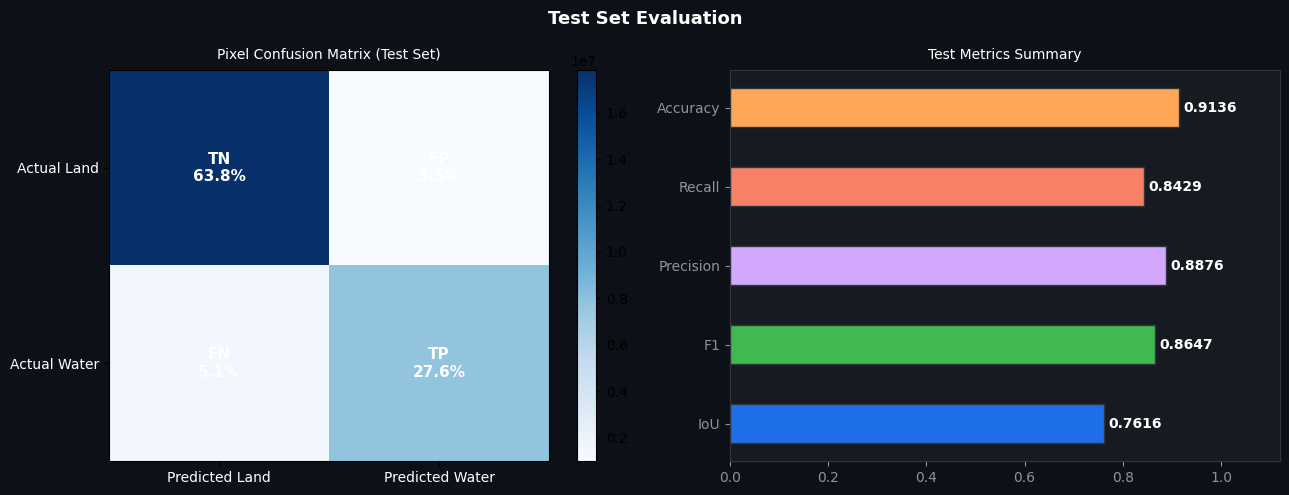

  ✅ Figure saved: test_evaluation.png


In [16]:
# Compute from test metrics accumulator
tp = test_metrics.tp
fp = test_metrics.fp
fn = test_metrics.fn
tn = test_metrics.tn
total = tp + fp + fn + tn

cm_vals   = np.array([[tn, fp], [fn, tp]])
cm_labels = np.array([[f"TN\n{tn/total*100:.1f}%",
                        f"FP\n{fp/total*100:.1f}%"],
                       [f"FN\n{fn/total*100:.1f}%",
                        f"TP\n{tp/total*100:.1f}%"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="#0d1117")
fig.suptitle("Test Set Evaluation", color="white",
             fontsize=13, fontweight="bold")

# Confusion matrix
ax = axes[0]
ax.set_facecolor("#161b22")
im = ax.imshow(cm_vals, cmap="Blues", aspect="auto")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted Land", "Predicted Water"],
                   color="white", fontsize=10)
ax.set_yticklabels(["Actual Land", "Actual Water"],
                   color="white", fontsize=10)
ax.set_title("Pixel Confusion Matrix (Test Set)",
             color="white", fontsize=10, pad=8)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_labels[i, j], ha="center", va="center",
                color="white", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax)

# Metrics bar chart
ax2 = axes[1]
ax2.set_facecolor("#161b22")
metric_names = ["IoU", "F1", "Precision", "Recall", "Accuracy"]
metric_vals  = [tm["iou"], tm["f1"], tm["precision"],
                tm["recall"], tm["accuracy"]]
colors = ["#1f6feb", "#3fb950", "#d2a8ff", "#f78166", "#ffa657"]
bars = ax2.barh(metric_names, metric_vals,
                color=colors, edgecolor="#30363d", height=0.5)
ax2.set_xlim(0, 1.12)
ax2.set_title("Test Metrics Summary",
              color="white", fontsize=10, pad=8)
ax2.tick_params(colors="#8b949e")
for bar, val in zip(bars, metric_vals):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center",
             color="white", fontsize=10, fontweight="bold")
for sp in ax2.spines.values(): sp.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("test_evaluation.png", dpi=120, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("  ✅ Figure saved: test_evaluation.png")

# Inference & Visual Overlay on Test Images

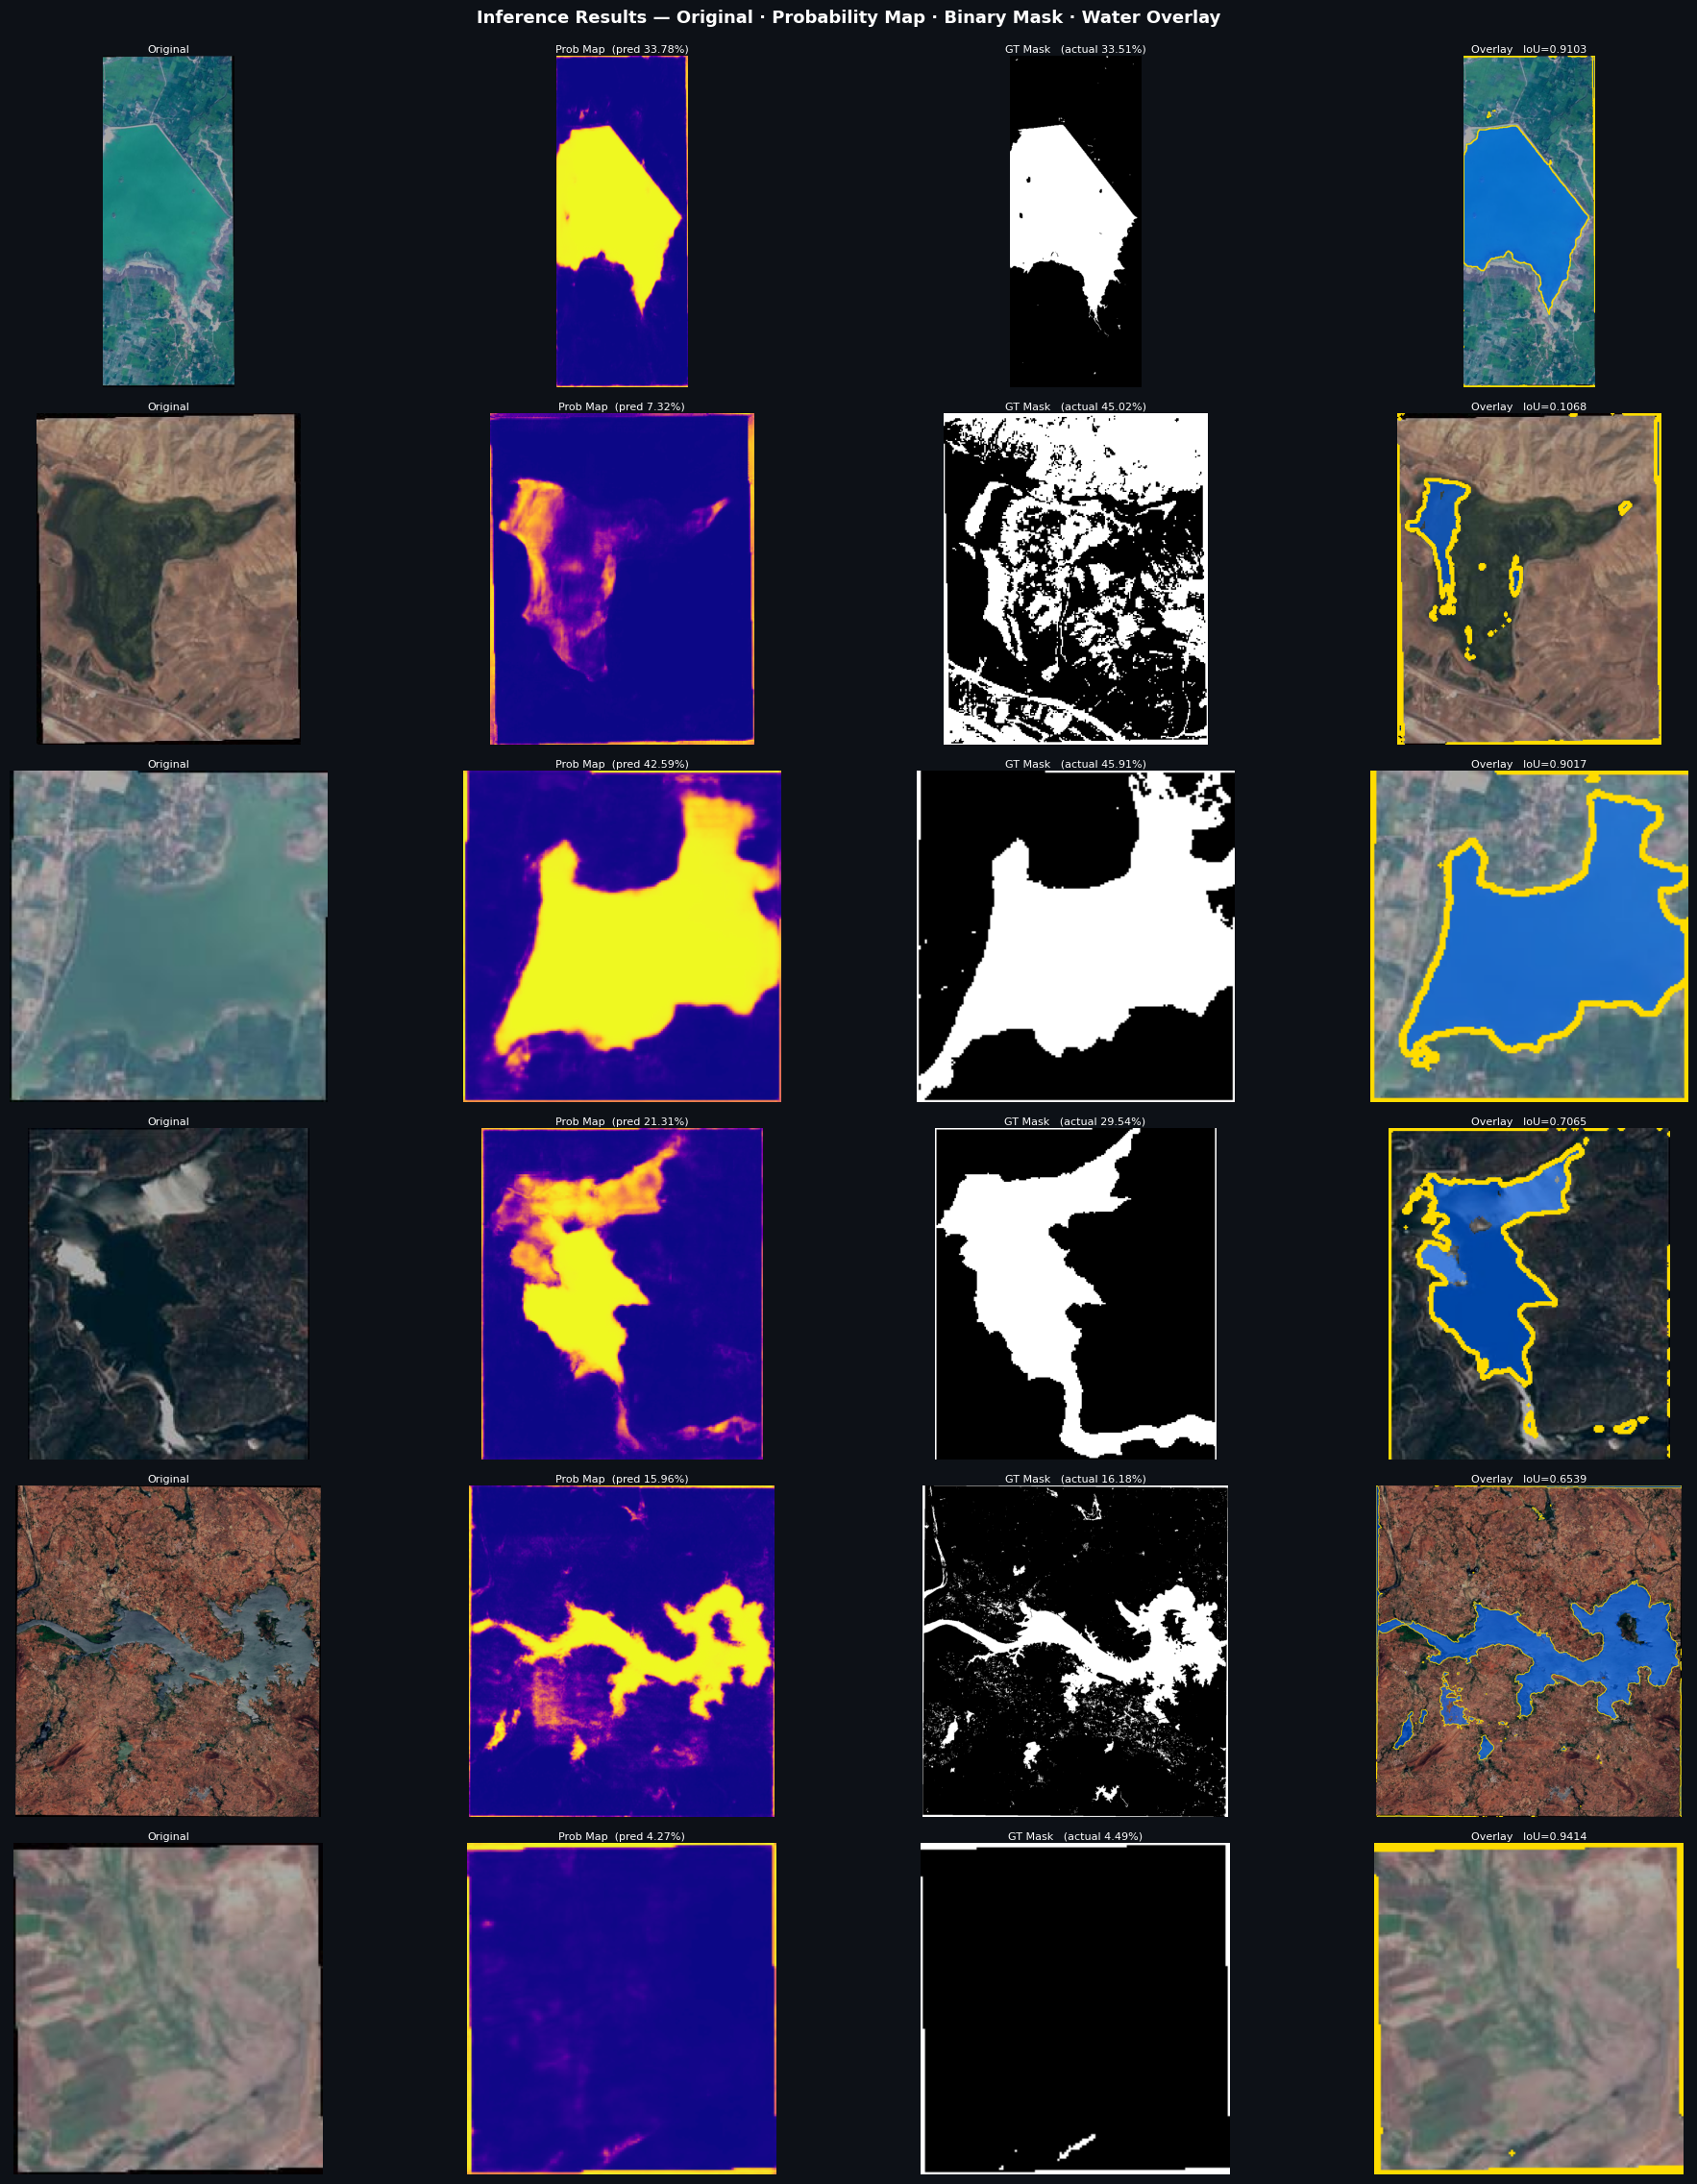

  ✅ Figure saved: inference_results.png


In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import random
from PIL import Image
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Make sure best model is loaded 
checkpoint = torch.load("/kaggle/working/best_model.pth",
                        map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Denormalization for display 
MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(tensor):
    return torch.clamp(tensor * STD_T + MEAN_T, 0, 1)

#   Single-image inference function
#      Accepts a file path OR raw numpy array (your own data)

def predict_single(source, threshold=0.5):
    """
    Run water segmentation on one image.

    Args:
        source    : file path (str/Path) OR HxWx3 uint8 RGB ndarray
        threshold : binarization threshold on sigmoid probability

    Returns:
        original_rgb  : HxWx3 uint8  — original image at native resolution
        prob_map      : HxW float32  — water probability ∈ [0,1]
        binary_mask   : HxW uint8    — 255=water, 0=land  (native resolution)
        overlay       : HxWx3 uint8  — semi-transparent blue overlay
        water_pct     : float        — % of image covered by water
    """
    # Load 
    if isinstance(source, (str, Path)):
        original_rgb = np.array(Image.open(source).convert("RGB"))
    else:
        original_rgb = source.copy()

    H, W = original_rgb.shape[:2]

    # Preprocess → tensor 
    img_pil = Image.fromarray(original_rgb)
    tf = __import__("torchvision").transforms.Compose([
        __import__("torchvision").transforms.Resize(
            (TILE_SIZE, TILE_SIZE),
            interpolation=__import__("torchvision").transforms.InterpolationMode.BILINEAR
        ),
        __import__("torchvision").transforms.ToTensor(),
        __import__("torchvision").transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])
    tensor = tf(img_pil).unsqueeze(0).to(DEVICE)   # [1,3,256,256]

    # Forward pass 
    with torch.no_grad():
        logits   = model(tensor)                         # [1,1,256,256] logits
        prob_256 = torch.sigmoid(logits).squeeze().cpu().numpy()  # [256,256]

    # Resize probability map back to original resolution 
    prob_map    = cv2.resize(prob_256, (W, H),
                             interpolation=cv2.INTER_LINEAR)

    # Binarize 
    binary_mask = (prob_map >= threshold).astype(np.uint8) * 255

    # Water percentage 
    water_pct = round((binary_mask == 255).mean() * 100, 2)

    # Overlay: semi-transparent blue on water pixels 
    overlay   = original_rgb.copy().astype(np.float32)
    water_px  = binary_mask == 255
    overlay[water_px] = (
        original_rgb[water_px].astype(np.float32) * 0.40
        + np.array([0, 100, 255], dtype=np.float32)     * 0.60
    )
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # Draw water boundary contours
    contours, _ = cv2.findContours(binary_mask,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    cv2.drawContours(overlay_bgr, contours, -1, (0, 220, 255), 2)
    overlay = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    return original_rgb, prob_map, binary_mask, overlay, water_pct


#      Visualize 6 random test samples — 4 panels each
#      [Original | Prob Map | Binary Mask | Overlay]
N_SHOW  = 6
samples = random.sample(list(zip(test_img, test_mask)), N_SHOW)

fig = plt.figure(figsize=(20, N_SHOW * 3.8), facecolor="#0d1117")
fig.suptitle(
    "Inference Results — Original · Probability Map · Binary Mask · Water Overlay",
    color="white", fontsize=13, fontweight="bold", y=0.995
)

for row, (img_p, mask_p) in enumerate(samples):

    # Ground truth mask (for reference)
    gt_mask = np.array(Image.open(mask_p).convert("L"))
    gt_bin  = (gt_mask > 127).astype(np.uint8) * 255
    gt_pct  = round((gt_bin == 255).mean() * 100, 2)

    # Prediction
    orig, prob, pred_bin, overlay, pred_pct = predict_single(img_p)

    # IoU for this single image
    pred_bool = pred_bin == 255
    gt_bool   = gt_bin   == 255
    inter = (pred_bool & gt_bool).sum()
    union = (pred_bool | gt_bool).sum()
    img_iou = round(inter / (union + 1e-6), 4)

    panels = [
        (orig,     f"Original",                      None,      None,   None),
        (prob,     f"Prob Map  (pred {pred_pct}%)",  "plasma",  0.0,    1.0),
        (gt_bin,   f"GT Mask   (actual {gt_pct}%)",  "gray",    0,      255),
        (overlay,  f"Overlay   IoU={img_iou}",        None,      None,   None),
    ]

    for col, (panel, title, cmap, vmin, vmax) in enumerate(panels):
        ax = fig.add_subplot(N_SHOW, 4, row * 4 + col + 1)
        kwargs = {"cmap": cmap}
        if vmin is not None:
            kwargs["vmin"] = vmin
            kwargs["vmax"] = vmax
        ax.imshow(panel, **kwargs)
        ax.set_title(title, color="white", fontsize=8, pad=3)
        ax.axis("off")
        for sp in ax.spines.values():
            sp.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("inference_results.png", dpi=110,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("  ✅ Figure saved: inference_results.png")


  Computing per-image IoU on full test set...
  Per-image IoU — Min : 0.0021
  Per-image IoU — Max : 1.0000
  Per-image IoU — Mean: 0.7405


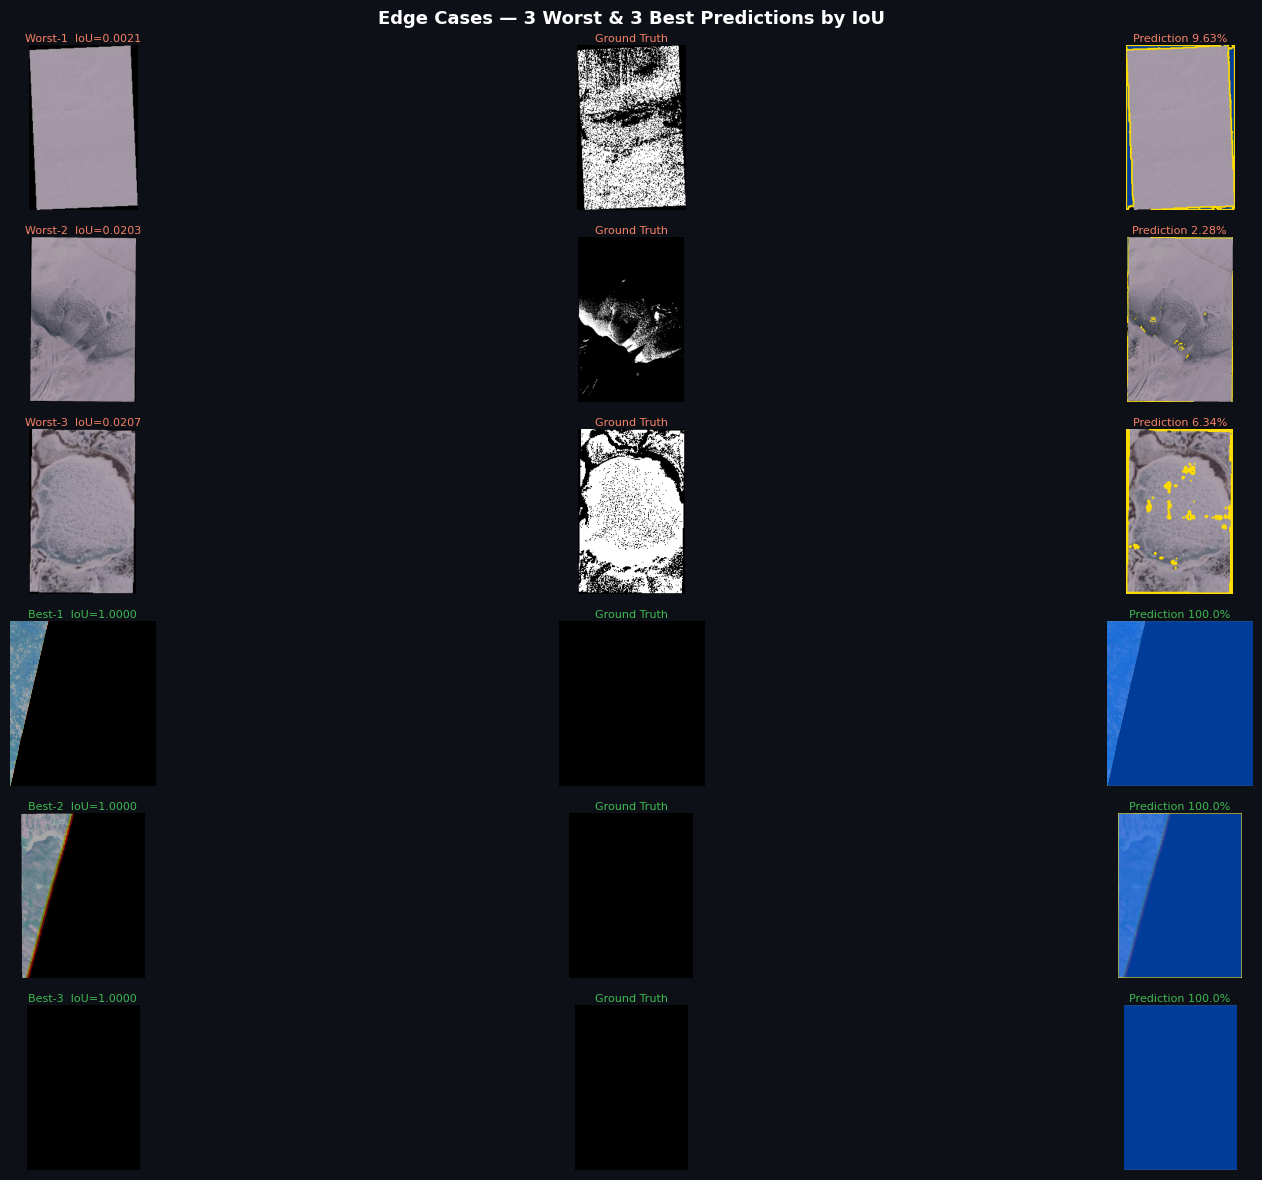

  ✅ Figure saved: edge_cases.png


In [20]:
#  Edge cases: best and worst predictions by IoU
print("\n  Computing per-image IoU on full test set...")

per_image_iou = []
for img_p, mask_p in zip(test_img, test_mask):
    gt_mask  = (np.array(Image.open(mask_p).convert("L")) > 127)
    _, _, pred_bin, _, _ = predict_single(img_p)
    pred_bool = pred_bin == 255

    # Resize gt to native resolution if needed
    if gt_mask.shape != pred_bool.shape:
        gt_mask = cv2.resize(gt_mask.astype(np.uint8),
                             (pred_bool.shape[1], pred_bool.shape[0]),
                             interpolation=cv2.INTER_NEAREST).astype(bool)

    inter = (pred_bool & gt_mask).sum()
    union = (pred_bool | gt_mask).sum()
    iou   = inter / (union + 1e-6)
    per_image_iou.append((iou, img_p, mask_p))

per_image_iou.sort(key=lambda x: x[0])

print(f"  Per-image IoU — Min : {per_image_iou[0][0]:.4f}")
print(f"  Per-image IoU — Max : {per_image_iou[-1][0]:.4f}")
print(f"  Per-image IoU — Mean: {np.mean([x[0] for x in per_image_iou]):.4f}")

# Show 3 best + 3 worst
edge_cases = per_image_iou[:3] + per_image_iou[-3:]
labels     = ["Worst-1","Worst-2","Worst-3",
              "Best-1", "Best-2", "Best-3"]

fig2 = plt.figure(figsize=(20, 6 * 2), facecolor="#0d1117")
fig2.suptitle("Edge Cases — 3 Worst & 3 Best Predictions by IoU",
              color="white", fontsize=13, fontweight="bold")

for row, ((iou, img_p, mask_p), label) in enumerate(zip(edge_cases, labels)):
    gt_mask  = (np.array(Image.open(mask_p).convert("L")) > 127).astype(np.uint8)*255
    orig, prob, pred_bin, overlay, pred_pct = predict_single(img_p)

    color = "#f78166" if row < 3 else "#3fb950"
    for col, (panel, title, cmap) in enumerate([
        (orig,    f"{label}  IoU={iou:.4f}", None),
        (gt_mask, "Ground Truth",            "gray"),
        (overlay, f"Prediction {pred_pct}%", None),
    ]):
        ax = fig2.add_subplot(6, 3, row * 3 + col + 1)
        ax.imshow(panel, cmap=cmap)
        ax.set_title(title, color=color, fontsize=8, pad=3)
        ax.axis("off")
        for sp in ax.spines.values():
            sp.set_edgecolor(color)

plt.tight_layout()
plt.savefig("edge_cases.png", dpi=110,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("  ✅ Figure saved: edge_cases.png")

# YOUR OWN IMAGE TEST

  Inference on Your Image
  File             : /kaggle/input/datasets/wessammahmoud/my-dataa/P1869_tile_000_003.png
  Image size       : 1024 × 1024 px
  Water coverage   : 75.58%
  Water pixels     : 792,499
  Land  pixels     : 256,077
  Total pixels     : 1,048,576


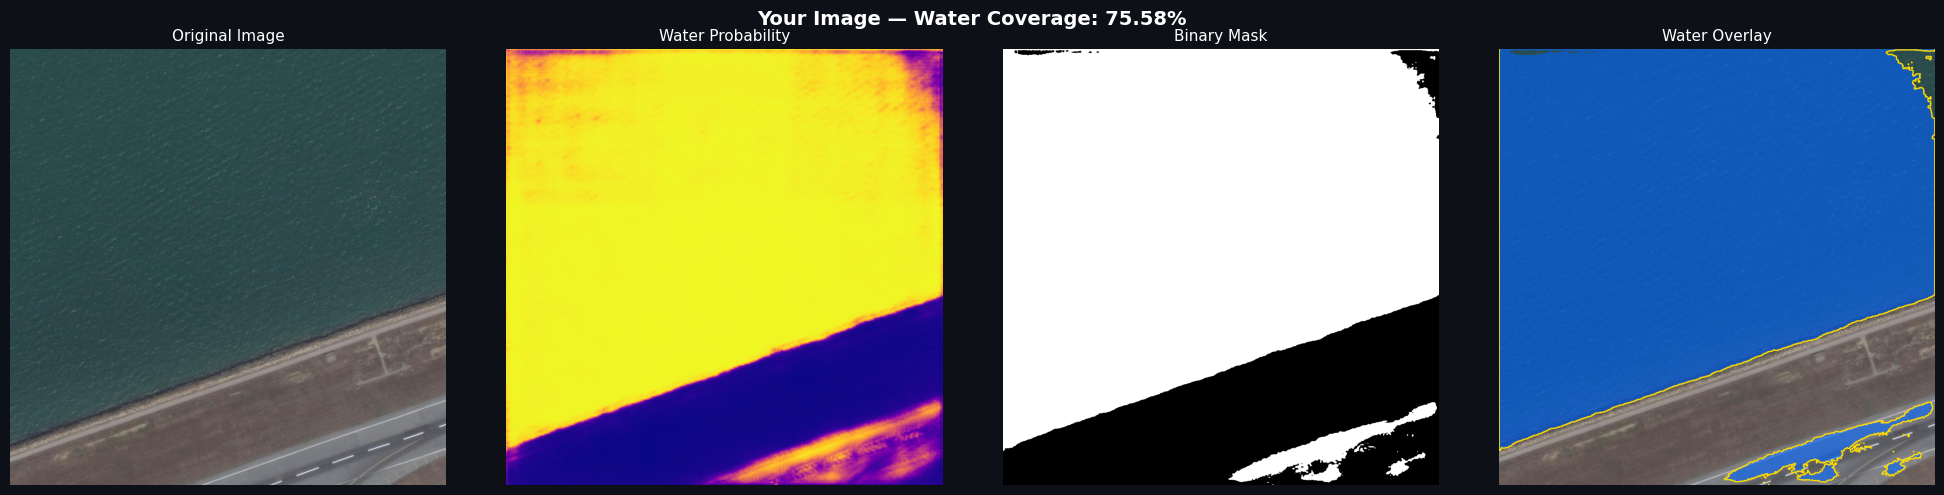

  ✅ Saved: my_image_prediction.png


In [23]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch, cv2

YOUR_IMAGE_PATH = "/kaggle/input/datasets/wessammahmoud/my-dataa/P1869_tile_000_003.png"   # ← change filename

# Run prediction
orig, prob, pred_bin, overlay, water_pct = predict_single(
    YOUR_IMAGE_PATH, threshold=0.5
)

H, W = orig.shape[:2]

print("=" * 55)
print("  Inference on Your Image")
print("=" * 55)
print(f"  File             : {YOUR_IMAGE_PATH}")
print(f"  Image size       : {W} × {H} px")
print(f"  Water coverage   : {water_pct}%")
print(f"  Water pixels     : {(pred_bin==255).sum():,}")
print(f"  Land  pixels     : {(pred_bin==0).sum():,}")
print(f"  Total pixels     : {pred_bin.size:,}")
print("=" * 55)

# Visualize — 4 panels
fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor="#0d1117")
fig.suptitle(f"Your Image — Water Coverage: {water_pct}%",
             color="white", fontsize=14, fontweight="bold")

panels = [
    (orig,     "Original Image",      None,     None, None),
    (prob,     "Water Probability",   "plasma",  0.0,  1.0),
    (pred_bin, "Binary Mask",         "gray",    0,    255),
    (overlay,  f"Water Overlay",      None,     None, None),
]

for ax, (panel, title, cmap, vmin, vmax) in zip(axes, panels):
    kwargs = {"cmap": cmap}
    if vmin is not None:
        kwargs["vmin"] = vmin
        kwargs["vmax"] = vmax
    ax.imshow(panel, **kwargs)
    ax.set_title(title, color="white", fontsize=11, pad=6)
    ax.axis("off")
    for sp in ax.spines.values():
        sp.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("my_image_prediction.png", dpi=130,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("  ✅ Saved: my_image_prediction.png")

# THRESHOLD CALIBRATION

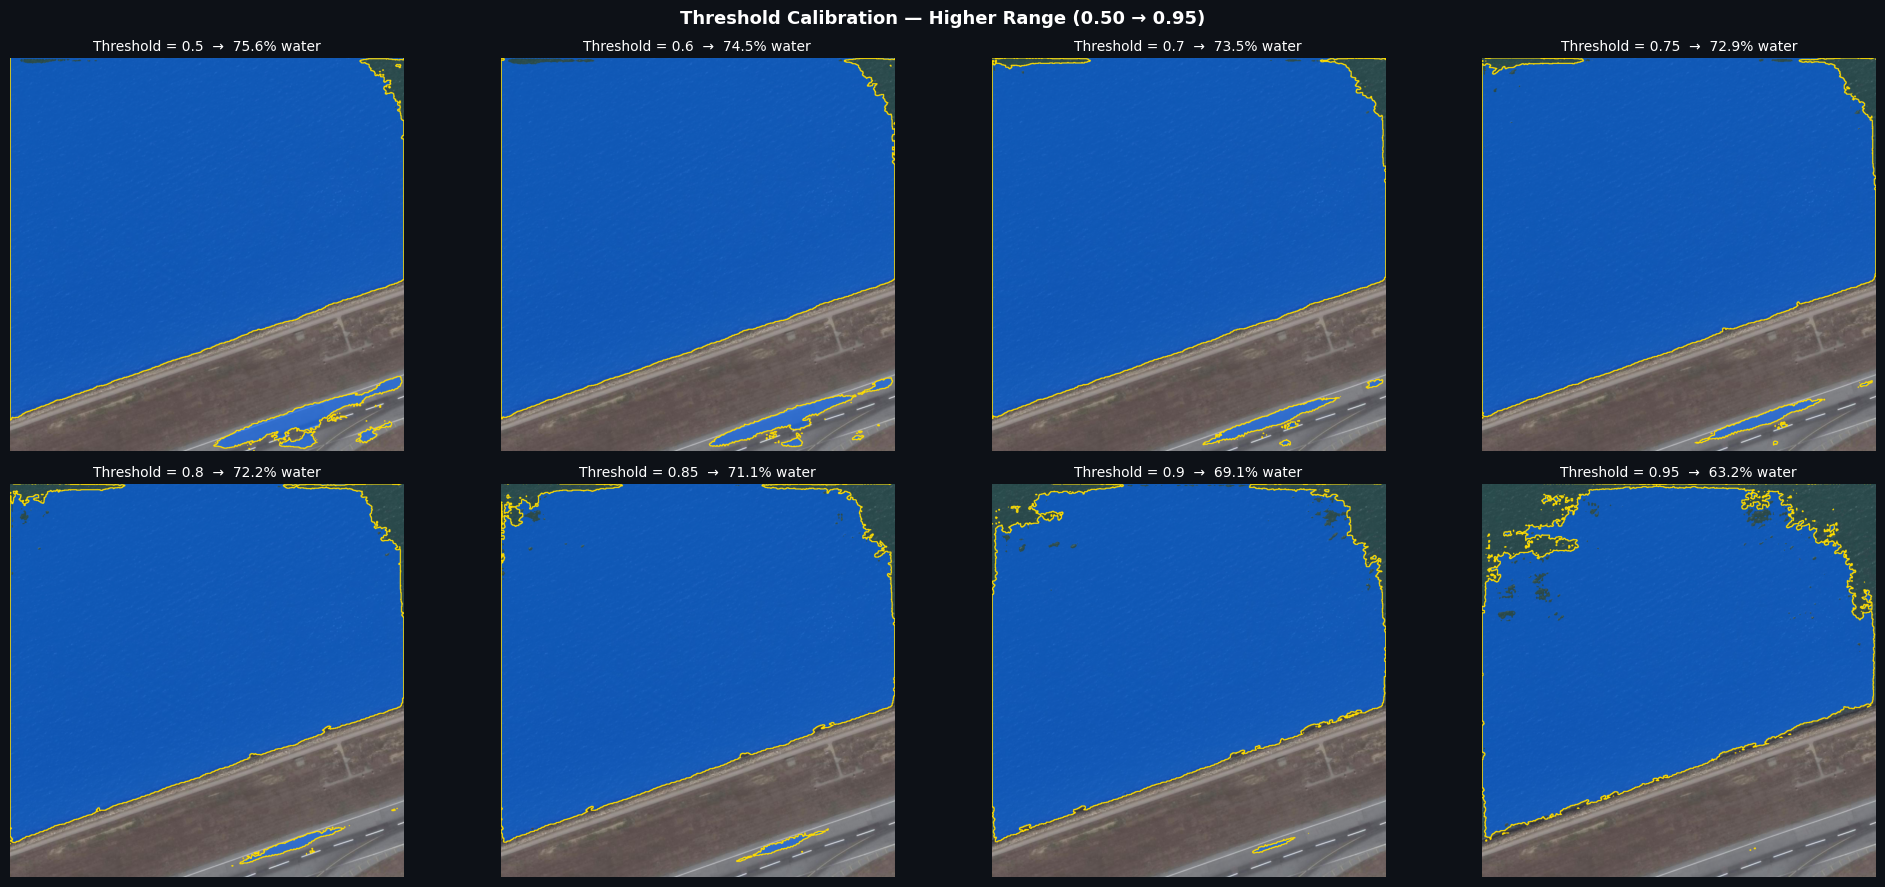

   Threshold │    Water % │     Water px
  ──────────────────────────────────────
        0.50 │     75.58% │      792,499
        0.60 │     74.50% │      781,190
        0.70 │     73.50% │      770,707
        0.75 │     72.93% │      764,736
        0.80 │     72.18% │      756,812
        0.85 │     71.07% │      745,197
        0.90 │     69.14% │      725,008
        0.95 │     63.22% │      662,954


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch, cv2
from PIL import Image
from torchvision import transforms as T

YOUR_IMAGE_PATH = "/kaggle/input/datasets/wessammahmoud/my-dataa/P1869_tile_000_003.png"

original_rgb = np.array(Image.open(YOUR_IMAGE_PATH).convert("RGB"))
H, W = original_rgb.shape[:2]

tf = T.Compose([
    T.Resize((TILE_SIZE, TILE_SIZE),
             interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])
tensor = tf(Image.fromarray(original_rgb)).unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    prob_map = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()
prob_map = cv2.resize(prob_map, (W, H), interpolation=cv2.INTER_LINEAR)

# Show 8 thresholds in a clean fixed 2×4 grid
show_thresholds = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

fig, axes = plt.subplots(2, 4, figsize=(20, 9), facecolor="#0d1117")
fig.suptitle("Threshold Calibration — Higher Range (0.50 → 0.95)",
             color="white", fontsize=13, fontweight="bold")

axes_flat = axes.flatten()

for i, t in enumerate(show_thresholds):
    binary  = (prob_map >= t).astype(np.uint8) * 255
    overlay = original_rgb.copy().astype(np.float32)
    wp      = binary == 255

    overlay[wp] = (
        original_rgb[wp].astype(np.float32) * 0.40
        + np.array([0, 100, 255], dtype=np.float32) * 0.60
    )
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # Contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    ov_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    cv2.drawContours(ov_bgr, contours, -1, (0, 220, 255), 2)
    overlay = cv2.cvtColor(ov_bgr, cv2.COLOR_BGR2RGB)

    water_pct = round(wp.mean() * 100, 1)

    ax = axes_flat[i]
    ax.imshow(overlay)
    ax.set_title(f"Threshold = {t}  →  {water_pct}% water",
                 color="white", fontsize=10, pad=5)
    ax.axis("off")
    for sp in ax.spines.values():
        sp.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("threshold_high_range.png", dpi=120,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

# Table
print("=" * 50)
print(f"  {'Threshold':>10} │ {'Water %':>10} │ {'Water px':>12}")
print("  " + "─" * 38)
for t in show_thresholds:
    mask = prob_map >= t
    pct  = mask.mean() * 100
    px   = mask.sum()
    print(f"  {t:>10.2f} │ {pct:>9.2f}% │ {px:>12,}")
print("=" * 50)

#  Save Model & Complete Inference Package

  Saved Model Files
  Full checkpoint  : /kaggle/working/best_model.pth
  Weights only     : /kaggle/working/water_segmentation_weights.pth
  Checkpoint size  : 372.6 MB
  Weights size     : 124.2 MB
  Config JSON      : /kaggle/working/model_config.json

  Running final inference with threshold=0.95 ...
  Saved: my_image_final_overlay.jpg
  Saved: my_image_final_mask.png
  Saved: my_image_final_probmap.png
  Saved: my_image_final_stats.json


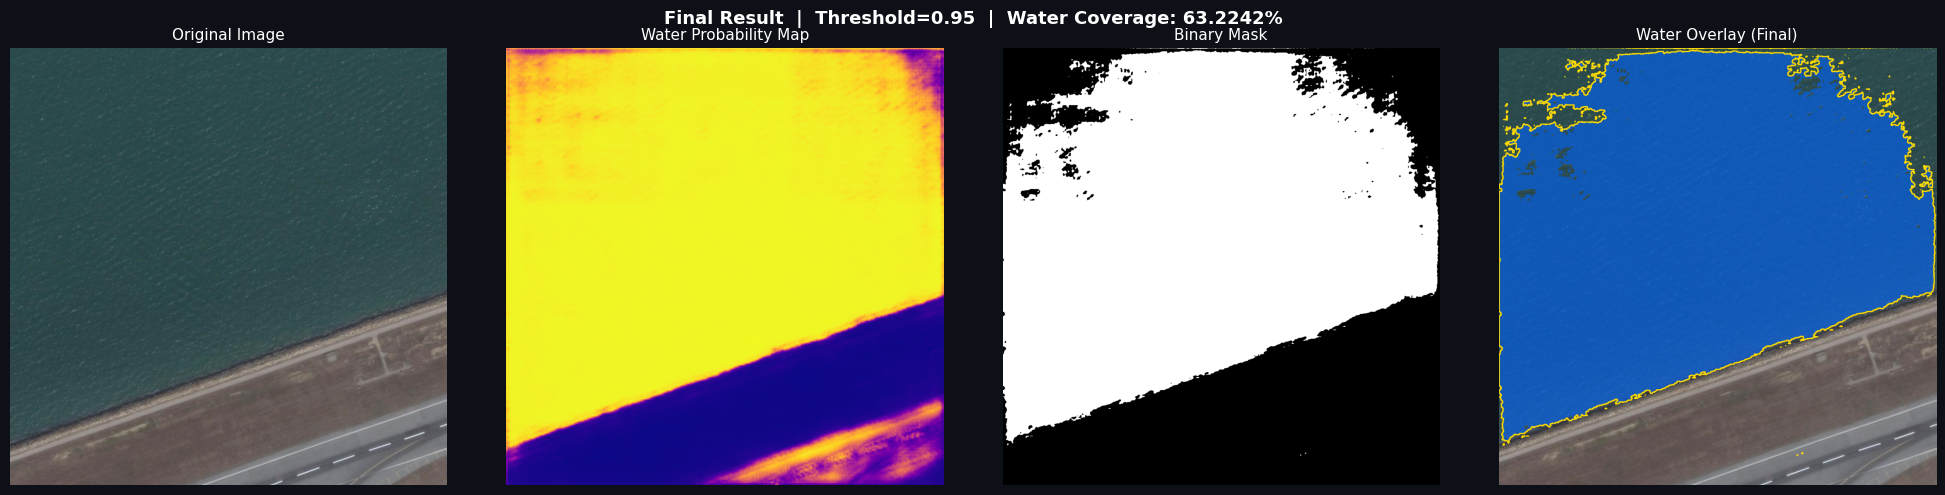


  ✅ PIPELINE COMPLETE — All Files Saved

  📁 Output directory: /kaggle/working

  Model files:
    best_model.pth                  ← full checkpoint
    water_segmentation_weights.pth  ← weights only
    model_config.json               ← config & metrics

  Your image results:
    my_image_final_overlay.jpg      ← visual overlay
    my_image_final_mask.png         ← binary mask
    my_image_final_probmap.png      ← probability map
    my_image_final_stats.json       ← coverage stats

  Model performance:
    Test IoU       : 0.7616
    Test F1        : 0.8647
    Test Accuracy  : 0.9136

  Your image result (threshold=0.95):
    Water coverage : 63.2242%
    Water pixels   : 662,954
    Land  pixels   : 385,622

  To use on a new image:
    model   = load_model('water_segmentation_weights.pth')
    results = predict_image('your_image.jpg', model,
                            threshold=0.95)

  ✅ Pipeline fully saved.


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import json
import os
from pathlib import Path
from PIL import Image
from torchvision import transforms as T

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
OUTPUT_DIR = Path("/kaggle/working")

#      Save full checkpoint (already saved during training)
#       + Save lightweight weights-only file

# Weights-only — smallest file, used for deployment
weights_path = OUTPUT_DIR / "water_segmentation_weights.pth"
torch.save(model.state_dict(), weights_path)

# Full checkpoint — includes config, metrics, history
full_ckpt_path = OUTPUT_DIR / "best_model.pth"  # already saved in Step 7

print("=" * 55)
print("  Saved Model Files")
print("=" * 55)
print(f"  Full checkpoint  : {full_ckpt_path}")
print(f"  Weights only     : {weights_path}")
print(f"  Checkpoint size  : {os.path.getsize(full_ckpt_path)/1e6:.1f} MB")
print(f"  Weights size     : {os.path.getsize(weights_path)/1e6:.1f} MB")

# Save model config as JSON
config = {
    "architecture"       : "U-Net",
    "in_channels"        : 3,
    "base_filters"       : 64,
    "tile_size"          : TILE_SIZE,
    "threshold_kaggle"   : 0.50,    # best for Kaggle test set
    "threshold_own_data" : 0.95,    # calibrated on your satellite data
    "normalization_mean" : [0.485, 0.456, 0.406],
    "normalization_std"  : [0.229, 0.224, 0.225],
    "trainable_params"   : 31_037_633,
    "training": {
        "dataset"        : "franciscoescobar/satellite-images-of-water-bodies",
        "total_images"   : 2841,
        "train_split"    : 1988,
        "val_split"      : 426,
        "test_split"     : 427,
        "epochs_trained" : 50,
        "best_epoch"     : 47,
        "optimizer"      : "AdamW",
        "lr"             : 1e-4,
        "loss"           : "BCEWithLogitsLoss + Dice (0.5/0.5)",
        "scheduler"      : "CosineAnnealingLR",
        "batch_size"     : 16,
        "tile_size"      : 256,
        "augmentation"   : ["HFlip","VFlip","Rot90","BrightnessContrast"],
    },
    "test_metrics": {
        "iou"       : 0.7616,
        "f1"        : 0.8647,
        "precision" : 0.8876,
        "recall"    : 0.8429,
        "accuracy"  : 0.9136,
    }
}

config_path = OUTPUT_DIR / "model_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"  Config JSON      : {config_path}")
print("=" * 55)


#       Self-contained inference function
def load_model(weights_path, device="cpu"):
    """
    Load the trained U-Net from a weights file.

    Usage:
        model = load_model("water_segmentation_weights.pth")
    """
    model = UNet(in_channels=3, base_filters=64).to(device)
    state = torch.load(weights_path, map_location=device)
    # Handle both weights-only and full checkpoint dicts
    if "model_state_dict" in state:
        state = state["model_state_dict"]
    model.load_state_dict(state)
    model.eval()
    print(f"  ✅ Model loaded from: {weights_path}")
    return model


def predict_image(source, model, device="cpu",
                  threshold=0.95, tile_size=256):
    """
    ================================================================
    MAIN INFERENCE FUNCTION — use this on your own satellite images
    ================================================================

    Args:
        source    : file path (str) OR numpy HxWx3 uint8 RGB array
        model     : loaded UNet (from load_model())
        device    : "cuda" or "cpu"
        threshold : 0.95 recommended for your satellite data
                    0.50 for Kaggle-style water body images
        tile_size : must match training tile size (256)

    Returns:
        results dict with keys:
            original_rgb  : HxWx3 uint8 — original image
            prob_map      : HxW float32 — water probability [0,1]
            binary_mask   : HxW uint8   — 255=water, 0=land
            overlay       : HxWx3 uint8 — blue water overlay
            water_pct     : float       — % water coverage
            water_pixels  : int         — count of water pixels
            land_pixels   : int         — count of land pixels
            total_pixels  : int         — H × W
    """
    # Load image 
    if isinstance(source, (str, Path)):
        original_rgb = np.array(Image.open(source).convert("RGB"))
    else:
        original_rgb = source.copy()

    H, W = original_rgb.shape[:2]

    # Preprocess 
    tf = T.Compose([
        T.Resize((tile_size, tile_size),
                 interpolation=T.InterpolationMode.BILINEAR),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])
    tensor = tf(Image.fromarray(original_rgb)).unsqueeze(0).to(device)

    #  Forward pass 
    model.eval()
    with torch.no_grad():
        logits   = model(tensor)
        prob_256 = torch.sigmoid(logits).squeeze().cpu().numpy()

    # Resize back to original resolution 
    prob_map    = cv2.resize(prob_256, (W, H),
                             interpolation=cv2.INTER_LINEAR)

    # Binarize 
    binary_mask = (prob_map >= threshold).astype(np.uint8) * 255

    # Stats 
    water_pixels = int((binary_mask == 255).sum())
    land_pixels  = int((binary_mask == 0).sum())
    total_pixels = H * W
    water_pct    = round(water_pixels / total_pixels * 100, 4)

    # Overlay 
    overlay  = original_rgb.copy().astype(np.float32)
    water_px = binary_mask == 255
    overlay[water_px] = (
        original_rgb[water_px].astype(np.float32) * 0.40
        + np.array([0, 100, 255], dtype=np.float32) * 0.60
    )
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # Draw contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    ov_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    cv2.drawContours(ov_bgr, contours, -1, (0, 220, 255), 2)
    overlay = cv2.cvtColor(ov_bgr, cv2.COLOR_BGR2RGB)

    return {
        "original_rgb" : original_rgb,
        "prob_map"     : prob_map,
        "binary_mask"  : binary_mask,
        "overlay"      : overlay,
        "water_pct"    : water_pct,
        "water_pixels" : water_pixels,
        "land_pixels"  : land_pixels,
        "total_pixels" : total_pixels,
    }


def save_results(results, output_dir, filename_stem="prediction"):
    """
    Save all inference outputs to disk.

    Saves:
        <stem>_overlay.jpg   — visual overlay
        <stem>_mask.png      — binary mask (255=water)
        <stem>_probmap.png   — probability heatmap
        <stem>_stats.json    — water coverage statistics
    """
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    # Overlay
    overlay_bgr = cv2.cvtColor(results["overlay"], cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(out / f"{filename_stem}_overlay.jpg"),
                overlay_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])

    # Binary mask
    cv2.imwrite(str(out / f"{filename_stem}_mask.png"),
                results["binary_mask"])

    # Probability heatmap
    prob_color = cv2.applyColorMap(
        (results["prob_map"] * 255).astype(np.uint8),
        cv2.COLORMAP_PLASMA
    )
    cv2.imwrite(str(out / f"{filename_stem}_probmap.png"), prob_color)

    # Stats JSON
    stats = {
        "water_percentage" : results["water_pct"],
        "water_pixels"     : results["water_pixels"],
        "land_pixels"      : results["land_pixels"],
        "total_pixels"     : results["total_pixels"],
        "image_height"     : results["original_rgb"].shape[0],
        "image_width"      : results["original_rgb"].shape[1],
    }
    with open(out / f"{filename_stem}_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    print(f"  Saved: {filename_stem}_overlay.jpg")
    print(f"  Saved: {filename_stem}_mask.png")
    print(f"  Saved: {filename_stem}_probmap.png")
    print(f"  Saved: {filename_stem}_stats.json")
    return stats


#  Final demo on your image with threshold=0.95
YOUR_IMAGE_PATH = "/kaggle/input/datasets/wessammahmoud/my-dataa/P1869_tile_000_003.png"

print("\n  Running final inference with threshold=0.95 ...")
results = predict_image(
    YOUR_IMAGE_PATH, model,
    device    = DEVICE,
    threshold = 0.95,
    tile_size = TILE_SIZE,
)

# Save outputs
stats = save_results(results, OUTPUT_DIR, filename_stem="my_image_final")

# Final visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor="#0d1117")
fig.suptitle(
    f"Final Result  |  Threshold=0.95  |  Water Coverage: {results['water_pct']}%",
    color="white", fontsize=13, fontweight="bold"
)

panels = [
    (results["original_rgb"], "Original Image",       None,      None, None),
    (results["prob_map"],     "Water Probability Map", "plasma",  0.0,  1.0),
    (results["binary_mask"],  "Binary Mask",           "gray",    0,    255),
    (results["overlay"],      "Water Overlay (Final)", None,      None, None),
]

for ax, (panel, title, cmap, vmin, vmax) in zip(axes, panels):
    kw = {"cmap": cmap}
    if vmin is not None:
        kw["vmin"] = vmin
        kw["vmax"] = vmax
    ax.imshow(panel, **kw)
    ax.set_title(title, color="white", fontsize=11, pad=6)
    ax.axis("off")
    for sp in ax.spines.values():
        sp.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "final_result.png"), dpi=130,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

# Final summary
print("\n" + "=" * 55)
print("  ✅ PIPELINE COMPLETE — All Files Saved")
print("=" * 55)
print(f"\n  📁 Output directory: {OUTPUT_DIR}")
print(f"\n  Model files:")
print(f"    best_model.pth                  ← full checkpoint")
print(f"    water_segmentation_weights.pth  ← weights only")
print(f"    model_config.json               ← config & metrics")
print(f"\n  Your image results:")
print(f"    my_image_final_overlay.jpg      ← visual overlay")
print(f"    my_image_final_mask.png         ← binary mask")
print(f"    my_image_final_probmap.png      ← probability map")
print(f"    my_image_final_stats.json       ← coverage stats")
print(f"\n  Model performance:")
print(f"    Test IoU       : 0.7616")
print(f"    Test F1        : 0.8647")
print(f"    Test Accuracy  : 0.9136")
print(f"\n  Your image result (threshold=0.95):")
print(f"    Water coverage : {results['water_pct']}%")
print(f"    Water pixels   : {results['water_pixels']:,}")
print(f"    Land  pixels   : {results['land_pixels']:,}")
print(f"\n  To use on a new image:")
print(f"    model   = load_model('water_segmentation_weights.pth')")
print(f"    results = predict_image('your_image.jpg', model,")
print(f"                            threshold=0.95)")
print("=" * 55)
print("\n  ✅ Pipeline fully saved.")

In [31]:
import os
import zipfile
from IPython.display import FileLink

source_dir = '/kaggle/working'
output_filename = 'all_outputs.zip'

with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir(source_dir):
        if file != output_filename and not file.startswith('.'):
            zipf.write(os.path.join(source_dir, file), file)

display(FileLink(output_filename))

/kaggle/working/all_outputs.zip